In [11]:
# 注册自定义 highfreq_ops.Cut，并写入 C.custom_ops；同时强制单线程/线程后端，避免多进程丢失注册
import sys, os
sys.path.append(r"C:\Users\ASUS\qlib\examples\highfreq")
from qlib.data.ops import Operators, register_all_ops
from qlib.config import C
from highfreq_ops import Cut as HFCut

# 先在当前进程注册（覆盖同名内置 Cut）
Operators.register([HFCut])

# 配置自定义算子，并刷新算子注册
C.custom_ops = [{"class": "Cut", "module_path": "highfreq_ops"}]
register_all_ops(C)

# 关键：避免 joblib 以多进程方式 spawn 子进程（Windows 下会丢全局注册）
C.kernels = 1
C.joblib_backend = "threading"

print("highfreq_ops.Cut registered; kernels=1, backend=threading.")


highfreq_ops.Cut registered; kernels=1, backend=threading.


In [1]:
import fire

import qlib
import pickle
from qlib.constant import REG_CN
from qlib.config import HIGH_FREQ_CONFIG

from qlib.utils import init_instance_by_config
from qlib.data.dataset.handler import DataHandlerLP
from qlib.data.ops import Operators
from qlib.data.data import Cal
from qlib.tests.data import GetData

from highfreq_ops import get_calendar_day, DayLast, FFillNan, BFillNan, Date, Select, IsNull, Cut

天勤数据下载

In [2]:
# ============================================
# KQDownloader_fixed.py 调用区块（Qlib兼容）
# ============================================
from pathlib import Path
import os
import sys
import subprocess
from datetime import datetime

# 自动识别路径（支持从 qlib/examples/highfreq/ 中运行）
nb_cwd = Path.cwd()
if (nb_cwd / 'scripts').exists() and (nb_cwd / 'qlib').exists():
    PROJECT_ROOT = nb_cwd
else:
    PROJECT_ROOT = nb_cwd
    if PROJECT_ROOT.name.lower() == 'highfreq' and PROJECT_ROOT.parent.name.lower() == 'examples':
        PROJECT_ROOT = PROJECT_ROOT.parents[1]

# === 参数配置 ===
SCRIPT = PROJECT_ROOT / "scripts" / "data_collector" / "KQ" / "KQdownloader.py"
RAW_DIR = PROJECT_ROOT.parent / "kq_raw_data_new"       # 临时保存天勤原始CSV
QLIB_DIR = PROJECT_ROOT.parent / "qlib_data_new"        # 输出为Qlib标准数据
POOL_CSV = Path(r"C:\Users\ASUS\qlib\examples\highfreq\newstocks.csv")

START = "2025-01-01"
END = "2025-10-28"
INTERVAL = "1min"          # Qlib分钟级数据
USERNAME = "xclight"
PASSWORD = "xclight666"
LIMIT_NUMS = None         # 下载股票数量限制（None 表示全部）



# === benchmark 配置 ===
BENCHMARK_CODE = "SSE.000300"  # 沪深300
BENCHMARK_DIR = QLIB_DIR / "benchmark"
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)  # 确保目录存在
BENCHMARK_FILE = BENCHMARK_DIR / f"{BENCHMARK_CODE}.csv"

# === 路径检查 ===
RAW_DIR.mkdir(parents=True, exist_ok=True)
QLIB_DIR.mkdir(parents=True, exist_ok=True)

print("📁 当前工作路径:", nb_cwd)
print("🧭 项目根目录:", PROJECT_ROOT)
print("📜 使用脚本:", SCRIPT)
print("📦 原始数据目录:", RAW_DIR)
print("📊 Qlib数据输出目录:", QLIB_DIR)
print("📋 股票池:", POOL_CSV)
print("📊 Benchmark:", BENCHMARK_CODE)


# === 构建命令 ===
cmd = [
    sys.executable, str(SCRIPT), 'run',
    '--source_dir', str(RAW_DIR),
    '--target_dir', str(QLIB_DIR),
    '--csv_stock_pool', str(POOL_CSV),
    '--start', START,
    '--end', END,
    '--interval', INTERVAL,
    '--username', USERNAME,
    '--password', PASSWORD,
    '--benchmark', BENCHMARK_CODE,  # ⚙️ 新增 benchmark 参数
    '--benchmark_dir', str(BENCHMARK_DIR)  # ⚙️ benchmark 存放路径
]
if LIMIT_NUMS:
    cmd += ['--limit_nums', str(LIMIT_NUMS)]

print("\n🚀 启动下载命令:\n", ' '.join(map(str, cmd)), "\n")

# === 启动下载过程（实时输出日志） ===
with subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1) as p:
    for line in p.stdout:
        print(line, end='')
    rc = p.wait()
    if rc != 0:
        raise RuntimeError(f"❌ Downloader failed with return code {rc}")

print("\n✅ 数据下载与 Qlib 格式转换已完成！")
print(f"📂 Qlib 数据位置: {QLIB_DIR}")
print(f"📊 Benchmark 数据位置: {BENCHMARK_FILE}")


📁 当前工作路径: c:\Users\ASUS\qlib\examples\highfreq
🧭 项目根目录: c:\Users\ASUS\qlib
📜 使用脚本: c:\Users\ASUS\qlib\scripts\data_collector\KQ\KQdownloader.py
📦 原始数据目录: c:\Users\ASUS\kq_raw_data_new
📊 Qlib数据输出目录: c:\Users\ASUS\qlib_data_new
📋 股票池: C:\Users\ASUS\qlib\examples\highfreq\newstocks.csv
📊 Benchmark: SSE.000300

🚀 启动下载命令:
 c:\Users\ASUS\miniconda3\python.exe c:\Users\ASUS\qlib\scripts\data_collector\KQ\KQdownloader.py run --source_dir c:\Users\ASUS\kq_raw_data_new --target_dir c:\Users\ASUS\qlib_data_new --csv_stock_pool C:\Users\ASUS\qlib\examples\highfreq\newstocks.csv --start 2025-01-01 --end 2025-10-28 --interval 1min --username xclight --password xclight666 --benchmark SSE.000300 --benchmark_dir c:\Users\ASUS\qlib_data_new\benchmark 

在使用天勤量化之前，默认您已经知晓并同意以下免责条款，如果不同意请立即停止使用：https://www.shinnytech.com/blog/disclaimer/
2025-11-03 14:04:43.951 | INFO     | __main__:run:125 - ⚙️ 未设置 limit_nums，默认下载全部股票
2025-11-03 14:04:43.951 | INFO     | __main__:run:127 - 📊 股票数: 89
2025-11-03 14:04:43.95

In [4]:
#下载数据预处理 转化成qlib数据格式完全一样
import os
import pandas as pd
import numpy as np
from pathlib import Path
import struct

# ====== 天勤数据目录（直接覆盖） ======
KQ_DATA_DIR = Path(r"C:\Users\ASUS\qlib_data_new")
RAW_DIR = Path(r"C:\Users\ASUS\kq_raw_data_new")

# ====== 工具函数 ======
def market_prefix_convert(code: str):
    """sse.xxx / szse.xxx → SHxxx / SZxxx (文件夹名用大写)"""
    code = code.upper()
    if code.startswith("SSE."):
        return "SH" + code.split(".")[1]
    elif code.startswith("SZSE."):
        return "SZ" + code.split(".")[1]
    else:
        return code.upper()

def market_prefix_convert_upper(code: str):
    """sse.xxx / szse.xxx → SHxxx / SZxxx (all.txt用大写)"""
    code = code.upper()
    if code.startswith("SSE."):
        return "SH" + code.split(".")[1]
    elif code.startswith("SZSE."):
        return "SZ" + code.split(".")[1]
    else:
        return code.upper()

# 测试转换函数
print("🧪 测试转换函数:")
test_codes = ["sse.000300", "szse.000001", "SSE.600519", "SZSE.000858"]
for code in test_codes:
    converted_folder = market_prefix_convert(code)
    converted_file = market_prefix_convert_upper(code)
    print(f"   {code} → 文件夹: {converted_folder}, all.txt: {converted_file}")

def write_bin(series: pd.Series, path: Path):
    """写入 float32 二进制"""
    path.parent.mkdir(parents=True, exist_ok=True)
    arr = series.astype(np.float32).to_numpy()
    with open(path, "wb") as f:
        f.write(struct.pack(f"{len(arr)}f", *arr))

def read_bin(fp):
    return np.fromfile(fp, dtype=np.float32)

# ====== 1. 日历文件保持不变 ======
print(f"✅ 日历文件已存在: {KQ_DATA_DIR / 'calendars' / '1min.txt'}")

# ====== 2. instruments/all.txt 转换 ======
inst_src = KQ_DATA_DIR / "instruments" / "all.txt"

# 使用更灵活的读取方式处理格式问题
print(f"🔍 检查股票池文件格式: {inst_src}")

# 先读取原始内容查看格式
with open(inst_src, 'r', encoding='utf-8') as f:
    lines = f.readlines()
    
print(f"   文件总行数: {len(lines)}")
print(f"   前3行原始内容:")
for i in range(min(3, len(lines))):
    print(f"     {repr(lines[i].strip())}")

# 手动解析每行，处理引号和格式问题
parsed_data = []
for line in lines:
    line = line.strip()
    if not line:
        continue
    
    # 分割字段，处理引号问题
    parts = line.split('\t')
    if len(parts) >= 3:
        instrument = parts[0].strip()
        start_time = parts[1].strip()
        end_time = parts[2].strip().strip('"').strip()  # 去除引号和空格
        
        # 清理end_time中的多余内容
        if '"' in end_time:
            end_time = end_time.split('"')[0].strip()
        
        parsed_data.append([instrument, start_time, end_time])
    else:
        print(f"⚠️ 跳过格式异常的行: {line}")

# 创建DataFrame
inst_df = pd.DataFrame(parsed_data, columns=["instrument", "start", "end"])

print(f"📝 解析完成，数据形状: {inst_df.shape}")
print(f"   前5行解析结果:")
for i in range(min(5, len(inst_df))):
    print(f"     {inst_df.iloc[i].tolist()}")

# 转换股票代码格式（all.txt用大写）
inst_df["instrument"] = inst_df["instrument"].apply(market_prefix_convert_upper)

# 保存转换后的文件
inst_df.to_csv(inst_src, sep="\t", header=False, index=False)
print(f"✅ 股票池格式已转换: {inst_src}")
print(f"   转换后形状: {inst_df.shape}")
print(f"   前5支股票: {inst_df['instrument'].head().tolist()}")

# ====== 3. features 特征字段补齐 ======
#修复后 原始写入bin第一行数据为0 现在改成直接从csv读取写入bin
feature_src = KQ_DATA_DIR / "features"
csv_dir = RAW_DIR  # CSV 文件目录

# 删除benchmark文件夹（如果存在）
benchmark_dir = KQ_DATA_DIR / "benchmark"
if benchmark_dir.exists():
    import shutil
    shutil.rmtree(benchmark_dir)
    print(f"🗑️ 已删除benchmark文件夹: {benchmark_dir}")

print(f"📁 开始处理特征目录: {feature_src}")

# 处理每个股票的特征文件（先处理，后重命名）
print(f"📁 开始处理特征文件...")

"""
for inst_dir in feature_src.iterdir():
    if not inst_dir.is_dir():
        continue

    files = {f.stem.split(".")[0]: f for f in inst_dir.glob("*.1min.bin")}
    print(f"📈 处理 {inst_dir.name}: {list(files.keys())}")

    # 加载基础字段
    open_ = read_bin(files.get("open"))
    high = read_bin(files.get("high"))
    low = read_bin(files.get("low"))
    close = read_bin(files.get("close"))
    vol = read_bin(files.get("volume"))

    # 构造补充字段
    factor = np.ones_like(close, dtype=np.float32)
    paused = np.zeros_like(close, dtype=np.float32)
    paused_num = np.zeros_like(close, dtype=np.float32)
    change = np.concatenate([[0], np.diff(close)])  # ✅ 与 Qlib 一致：涨跌额

    # 写入
    write_bin(pd.Series(open_), inst_dir / "open.1min.bin")
    write_bin(pd.Series(high), inst_dir / "high.1min.bin")
    write_bin(pd.Series(low), inst_dir / "low.1min.bin")
    write_bin(pd.Series(close), inst_dir / "close.1min.bin")
    write_bin(pd.Series(vol), inst_dir / "volume.1min.bin")
    write_bin(pd.Series(factor), inst_dir / "factor.1min.bin")
    write_bin(pd.Series(paused), inst_dir / "paused.1min.bin")
    write_bin(pd.Series(paused_num), inst_dir / "paused_num.1min.bin")
    write_bin(pd.Series(change), inst_dir / "change.1min.bin")

print(f"✅ 特征文件处理完成")
"""
first_stock_done = False 

# 遍历 CSV 文件，批量生成 bin 文件
for csv_path in csv_dir.glob("*.csv"):  # 遍历所有 CSV
    inst_name = csv_path.stem  # 例如 SSE_000300
    inst_dir = feature_src / inst_name
    inst_dir.mkdir(parents=True, exist_ok=True)

    import pandas as pd
    df = pd.read_csv(csv_path)
    

    # 将 CSV 中的各列转换为 numpy float32
    open_np = df["open"].to_numpy(dtype=np.float32)
    high_np = df["high"].to_numpy(dtype=np.float32)
    low_np = df["low"].to_numpy(dtype=np.float32)
    close_np = df["close"].to_numpy(dtype=np.float32)
    vol_np = df["volume"].to_numpy(dtype=np.float32)

    # 构造补充字段
    factor_np = np.ones_like(close_np, dtype=np.float32)
    paused_np = np.zeros_like(close_np, dtype=np.float32)
    paused_num_np = np.zeros_like(close_np, dtype=np.float32)
    change_np = np.concatenate([[0], np.diff(close_np)])

    bin_data_list = [
        (open_np, "open"), (high_np, "high"), (low_np, "low"),
        (close_np, "close"), (vol_np, "volume"),
        (factor_np, "factor"), (paused_np, "paused"),
        (paused_num_np, "paused_num"), (change_np, "change")
    ]

    # 写入 bin 文件
    for arr, name in bin_data_list:
        path = inst_dir / f"{name}.1min.bin"
        write_bin(pd.Series(arr), path)

    # 打印第一个股票的 bin 数据前5行
    if not first_stock_done:
        print(f"\n📄 示例: {inst_name} 9 个 bin 文件前5条数据:")
        for arr, name in bin_data_list:
            print(f"   {name}: {arr[:5]}")
        first_stock_done = True

print(f"✅ 特征文件处理完成")

# 现在重命名所有文件夹为大写格式
print(f"\n🔄 开始重命名文件夹为大写格式...")

# 收集所有需要重命名的目录
rename_operations = []
print(f"🔍 检查所有目录:")
for inst_dir in feature_src.iterdir():
    if not inst_dir.is_dir():
        continue
    
    # 转换文件夹名称为Qlib标准格式（大写）
    inst_code = market_prefix_convert(inst_dir.name)
    target_dir = feature_src / inst_code
    
    print(f"   目录: {inst_dir.name} → 转换后: {inst_code}")
    
    if inst_dir != target_dir:
        rename_operations.append((inst_dir, target_dir))
        print(f"   ✅ 需要重命名: {inst_dir.name} → {inst_code}")
    else:
        print(f"   ⏭️ 无需重命名: {inst_dir.name}")

print(f"🔄 需要重命名的目录数量: {len(rename_operations)}")

# 显示重命名计划
if rename_operations:
    print(f"📋 重命名计划:")
    for i, (inst_dir, target_dir) in enumerate(rename_operations[:10]):  # 只显示前10个
        print(f"   {i+1}. {inst_dir.name} → {target_dir.name}")
    if len(rename_operations) > 10:
        print(f"   ... 还有 {len(rename_operations) - 10} 个目录")

# 执行重命名操作
for inst_dir, target_dir in rename_operations:
    try:
        print(f"📝 重命名: {inst_dir.name} → {target_dir.name}")
        os.rename(inst_dir, target_dir)
    except Exception as e:
        print(f"❌ 重命名失败 {inst_dir.name}: {e}")

print(f"✅ 目录重命名完成")

print("🎉 天勤分钟数据预处理完成，已覆盖为 Qlib 兼容格式！")

# ====== 4. 验证数据转换结果 ======
print("\n🔍 开始验证数据转换结果...")

# 验证日历文件
calendar_file = KQ_DATA_DIR / "calendars" / "1min.txt"
if calendar_file.exists():
    with open(calendar_file, 'r') as f:
        calendar_lines = f.readlines()
    print(f"✅ 日历文件验证: {len(calendar_lines)} 个交易日")
    print(f"   最早交易日: {calendar_lines[0].strip()}")
    print(f"   最晚交易日: {calendar_lines[-1].strip()}")
else:
    print("❌ 日历文件不存在")

# 验证股票池文件
instruments_file = KQ_DATA_DIR / "instruments" / "all.txt"
if instruments_file.exists():
    inst_df_check = pd.read_csv(instruments_file, header=None, sep='\t')
    print(f"✅ 股票池文件验证: {len(inst_df_check)} 支股票")
    print(f"   前5支股票: {inst_df_check.iloc[:5, 0].tolist()}")
else:
    print("❌ 股票池文件不存在")

# 验证特征文件
feature_dir = KQ_DATA_DIR / "features"
if feature_dir.exists():
    stock_dirs = [d for d in feature_dir.iterdir() if d.is_dir()]
    print(f"✅ 特征目录验证: {len(stock_dirs)} 个股票目录")
    
    # 检查第一个股票的特征文件
    if stock_dirs:
        first_stock = stock_dirs[0]
        feature_files = list(first_stock.glob("*.1min.bin"))
        print(f"   示例股票 {first_stock.name} 的特征文件:")
        for f in feature_files:
            file_size = f.stat().st_size
            data_points = file_size // 4  # float32 = 4 bytes
            print(f"     {f.name}: {data_points} 个数据点")
            
        # 验证数据内容
        try:
            close_data = read_bin(first_stock / "close.1min.bin")
            print(f"    {first_stock.name} close 数据范围: {close_data.min():.2f} ~ {close_data.max():.2f}")
            print(f"    数据点数: {len(close_data)}")
        except Exception as e:
            print(f"   ❌ 读取数据失败: {e}")
else:
    print("❌ 特征目录不存在")

# 验证benchmark文件夹（已删除）
benchmark_dir = KQ_DATA_DIR / "benchmark"
if benchmark_dir.exists():
    print("⚠️ Benchmark文件夹仍然存在")
else:
    print("✅ Benchmark文件夹已删除（符合Qlib标准）")

# 最终验证总结
print(f"\n📊 数据转换验证总结:")
print(f"   数据目录: {KQ_DATA_DIR}")
print(f"   日历文件: {'✅' if calendar_file.exists() else '❌'}")
print(f"   股票池文件: {'✅' if instruments_file.exists() else '❌'}")
print(f"   特征目录: {'✅' if feature_dir.exists() else '❌'}")
print(f"   Benchmark文件夹: {'❌' if benchmark_dir.exists() else '✅'} (已删除)")

# 检查文件夹命名格式
print(f"\n🔍 检查文件夹命名格式:")
if feature_dir.exists():
    stock_dirs = [d for d in feature_dir.iterdir() if d.is_dir()]
    if stock_dirs:
        print(f"   前5个文件夹名称:")
        for i, d in enumerate(stock_dirs[:5]):
            print(f"     {i+1}. {d.name}")
        
        # 检查是否符合Qlib标准格式（文件夹用大写）
        non_standard = [d.name for d in stock_dirs if not (d.name.startswith('SH') or d.name.startswith('SZ'))]
        if non_standard:
            print(f"   ⚠️ 发现非标准格式文件夹: {non_standard[:5]}")
        else:
            print(f"   ✅ 所有文件夹都符合Qlib标准格式 (SH/SZ开头，大写)")
    else:
        print("   ❌ 没有找到股票文件夹")

# 检查是否有任何文件被修改
import time
current_time = time.time()
recent_files = []

for root, dirs, files in os.walk(KQ_DATA_DIR):
    for file in files:
        file_path = Path(root) / file
        if file_path.stat().st_mtime > current_time - 300:  # 5分钟内的文件
            recent_files.append(str(file_path))

if recent_files:
    print(f"\n🔄 最近5分钟内修改的文件 ({len(recent_files)} 个):")
    for f in recent_files[:10]:  # 只显示前10个
        print(f"   {f}")
    if len(recent_files) > 10:
        print(f"   ... 还有 {len(recent_files) - 10} 个文件")
else:
    print(f"\n⚠️ 警告: 最近5分钟内没有文件被修改，可能数据转换未成功执行")

print("\n🎯 验证完成！如果所有项目都显示 ✅，说明数据转换成功。")



🧪 测试转换函数:
   sse.000300 → 文件夹: SH000300, all.txt: SH000300
   szse.000001 → 文件夹: SZ000001, all.txt: SZ000001
   SSE.600519 → 文件夹: SH600519, all.txt: SH600519
   SZSE.000858 → 文件夹: SZ000858, all.txt: SZ000858
✅ 日历文件已存在: C:\Users\ASUS\qlib_data_new\calendars\1min.txt
🔍 检查股票池文件格式: C:\Users\ASUS\qlib_data_new\instruments\all.txt
   文件总行数: 180
   前3行原始内容:
     'SSE.000300,2025-01-02 09:30:00,2025-10-27 14:59:00'
     'SSE.600000,2025-01-02 09:30:00,2025-10-27 14:59:00'
     'SSE.600021,2025-01-02 09:30:00,2025-10-27 14:59:00'
⚠️ 跳过格式异常的行: SSE.000300,2025-01-02 09:30:00,2025-10-27 14:59:00
⚠️ 跳过格式异常的行: SSE.600000,2025-01-02 09:30:00,2025-10-27 14:59:00
⚠️ 跳过格式异常的行: SSE.600021,2025-01-02 09:30:00,2025-10-27 14:59:00
⚠️ 跳过格式异常的行: SSE.600036,2025-01-02 09:30:00,2025-10-27 14:59:00
⚠️ 跳过格式异常的行: SSE.600111,2025-01-02 09:30:00,2025-10-27 14:59:00
⚠️ 跳过格式异常的行: SSE.600118,2025-01-02 09:30:00,2025-10-27 14:59:00
⚠️ 跳过格式异常的行: SSE.600143,2025-01-02 09:30:00,2025-10-27 14:59:00
⚠️ 跳过格式异常的行: SSE.600150,2

In [5]:
# 检查实际分隔符
with open(inst_src, 'r', encoding='utf-8') as f:
    first_line = f.readline()
    print(f"第一行原始内容: {repr(first_line)}")
    print(f"是否包含逗号: {',' in first_line}")
    print(f"是否包含tab: {'\t' in first_line}")
    print(f"按逗号分割: {first_line.split(',')}")
    print(f"按tab分割: {first_line.split('\t')}")

第一行原始内容: 'SH000300\t2025-01-02 09:30:00\t2025-10-27 14:59:00\n'
是否包含逗号: False
是否包含tab: True
按逗号分割: ['SH000300\t2025-01-02 09:30:00\t2025-10-27 14:59:00\n']
按tab分割: ['SH000300', '2025-01-02 09:30:00', '2025-10-27 14:59:00\n']


In [6]:


from pathlib import Path

FEATURES_DIR = Path(r"C:\Users\ASUS\qlib_data_new\features")

for folder in FEATURES_DIR.iterdir():
    if folder.is_dir():
        temp_name = folder.name + "_tmp"
        temp_path = folder.parent / temp_name
        folder.rename(temp_path)  # 先改临时名字
        final_name = folder.name.upper()
        final_path = folder.parent / final_name
        temp_path.rename(final_path)  # 再改成大写
        print(f"✅ 重命名: {folder.name} -> {final_name}")

print("🎉 features 文件夹全部改为大写完成！")



✅ 重命名: SH000300 -> SH000300
✅ 重命名: SH600000 -> SH600000
✅ 重命名: SH600021 -> SH600021
✅ 重命名: SH600036 -> SH600036
✅ 重命名: SH600111 -> SH600111
✅ 重命名: SH600118 -> SH600118
✅ 重命名: SH600143 -> SH600143
✅ 重命名: SH600150 -> SH600150
✅ 重命名: SH600160 -> SH600160
✅ 重命名: SH600183 -> SH600183
✅ 重命名: SH600519 -> SH600519
✅ 重命名: SH600580 -> SH600580
✅ 重命名: SH600629 -> SH600629
✅ 重命名: SH600760 -> SH600760
✅ 重命名: SH600893 -> SH600893
✅ 重命名: SH600895 -> SH600895
✅ 重命名: SH600900 -> SH600900
✅ 重命名: SH600938 -> SH600938
✅ 重命名: SH601059 -> SH601059
✅ 重命名: SH601061 -> SH601061
✅ 重命名: SH601088 -> SH601088
✅ 重命名: SH601127 -> SH601127
✅ 重命名: SH601138 -> SH601138
✅ 重命名: SH601689 -> SH601689
✅ 重命名: SH601888 -> SH601888
✅ 重命名: SH601995 -> SH601995
✅ 重命名: SH603019 -> SH603019
✅ 重命名: SH603099 -> SH603099
✅ 重命名: SH603200 -> SH603200
✅ 重命名: SH603256 -> SH603256
✅ 重命名: SH603444 -> SH603444
✅ 重命名: SH603667 -> SH603667
✅ 重命名: SH603893 -> SH603893
✅ 重命名: SH603986 -> SH603986
✅ 重命名: SH688008 -> SH688008
✅ 重命名: SH688012 -> S

数据地址 时间段配置

In [5]:
# 注册自定义算子（来自 examples/highfreq/highfreq_ops.py）
import importlib, highfreq_ops as _hf
_hf = importlib.reload(_hf)
import sys
sys.path.append(r"C:\Users\ASUS\qlib\examples\highfreq")
from qlib.data.ops import Operators, register_all_ops
from qlib.config import C
from highfreq_ops import Cut as HFCut, IntradayWindowVWAP as HFVWAP, DayShift as HFShift

# 当前进程注册，覆盖内置同名实现
Operators.register([HFCut, HFVWAP, HFShift])

# 写入全局配置，便于并行/子进程可见；仅刷新算子注册
C.custom_ops = [
    {"class": "Cut", "module_path": "highfreq_ops"},
    {"class": "IntradayWindowVWAP", "module_path": "highfreq_ops"},
    {"class": "DayShift", "module_path": "highfreq_ops"},
]
register_all_ops(C)
print("Registered custom ops: Cut, IntradayWindowVWAP, DayShift from highfreq_ops.")


Registered custom ops: Cut, IntradayWindowVWAP, DayShift from highfreq_ops.


In [1]:
import os
import sys
import qlib
import pandas as pd
from qlib.constant import REG_CN
from qlib.workflow import R
from qlib.utils import flatten_dict, init_instance_by_config
from qlib.workflow.record_temp import SignalRecord, PortAnaRecord
from qlib.contrib.strategy.signal_strategy import TopkDropoutStrategy
from qlib.contrib.evaluate import risk_analysis
from qlib.contrib.model.gbdt import LGBModel
from qlib.backtest import backtest
from workflow import HighfreqWorkflow
from highfreq_ops import IntradayWindowVWAP, DayShift
from qlib.data.ops import Operators


# 确保当前路径包含 workflow.py
WORKDIR = r"C:\Users\ASUS\qlib\examples\highfreq"
sys.path.append(WORKDIR)

# 导入自定义操作符
from highfreq_ops import get_calendar_day, DayLast, FFillNan, BFillNan, Date, Select, IsNull, Cut,DayFirst,IntradayWindowVWAP, DayShift,If


# 配置自定义操作符
SPEC_CONF = {"custom_ops": [DayLast, DayFirst,FFillNan, BFillNan, Date, Select, IsNull , DayShift ,Cut,IntradayWindowVWAP,If],"expression_cache": None}

print("✅ 自定义操作符已配置")

# 天勤数据配置
KQ_DATA_DIR = r"C:\Users\ASUS\qlib_data_ipynb"
STOCK_POOL_CSV = r"C:\Users\ASUS\qlib\examples\highfreq\sorted_high_preclose_ratio_2025.csv"

# 天勤数据时间段配置
START_TIME = "2025-01-02 09:30:00"
END_TIME = "2025-10-27 14:57:00"
TRAIN_END_TIME = "2025-07-15 14:59:00"  # 1-4月用于训练
TEST_START_TIME = "2025-07-16 09:30:00"  # 5-9月用于测试和回测

print(f"🔧 天勤数据配置:")
print(f"📂 数据目录: {KQ_DATA_DIR}")
print(f"📋 股票池: {STOCK_POOL_CSV}")
print(f"📅 训练时间段: {START_TIME} ~ {TRAIN_END_TIME}")
print(f"📅 测试时间段: {TEST_START_TIME} ~ {END_TIME}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


ModuleNotFoundError. CatBoostModel are skipped. (optional: maybe installing CatBoostModel can fix it.)
ModuleNotFoundError. XGBModel is skipped(optional: maybe installing xgboost can fix it).
ModuleNotFoundError.  PyTorch models are skipped (optional: maybe installing pytorch can fix it).
✅ 自定义操作符已配置
🔧 天勤数据配置:
📂 数据目录: C:\Users\ASUS\qlib_data_ipynb
📋 股票池: C:\Users\ASUS\qlib\examples\highfreq\sorted_high_preclose_ratio_2025.csv
📅 训练时间段: 2025-01-02 09:30:00 ~ 2025-07-15 14:59:00
📅 测试时间段: 2025-07-16 09:30:00 ~ 2025-10-27 14:57:00


初始化qlib（数据路径自定义 SPEC CONF自定义操作符配置） 筛选有效股票

In [2]:
# 强制使用自定义路径，避免 HIGH_FREQ_CONFIG 的默认路径覆盖
print("🔧 强制设置自定义数据路径...")

# 方法1：直接设置配置，不使用 HIGH_FREQ_CONFIG
CUSTOM_QLIB_CONFIG = {
    "provider_uri": KQ_DATA_DIR,  # 强制使用天勤数据路径
    "dataset_cache": None,
    "expression_cache": "DiskExpressionCache",
    "region": REG_CN,
    **SPEC_CONF  # 添加自定义操作符配置
}

print(f"📂 强制使用数据路径: {KQ_DATA_DIR}")
print(f"🔧 配置内容: {CUSTOM_QLIB_CONFIG}")

# 尝试初始化，如果失败则使用备用方案
try:
    qlib.init(**CUSTOM_QLIB_CONFIG, joblib_backend="threading")
    print(f"✅ Qlib 已初始化，使用天勤数据: {KQ_DATA_DIR}")
except Exception as e:
    print(f"⚠️ 自定义路径初始化失败: {e}")
    print("🔄 尝试备用方案：使用默认配置但指定数据路径...")
    
    # 备用方案：使用 HIGH_FREQ_CONFIG 但强制覆盖路径
    from qlib.config import HIGH_FREQ_CONFIG
    BACKUP_CONFIG = HIGH_FREQ_CONFIG.copy()
    BACKUP_CONFIG["provider_uri"] = KQ_DATA_DIR
    BACKUP_CONFIG.update(SPEC_CONF)
    
    qlib.init(**BACKUP_CONFIG)
    print(f"✅ 使用备用配置初始化成功")

print(f"✅ 自定义操作符已加载")

# 验证数据路径是否正确生效

from qlib.config import C
C.maxtasksperchild = 1  # 避免长进程累积资源
print(f"🔍 验证：当前 Qlib 数据路径: {C.provider_uri}")

# 如果路径仍然不对，提供手动检查
if str(C.provider_uri) != KQ_DATA_DIR:
    print(f"⚠️ 警告：数据路径不匹配！")
    print(f"  期望路径: {KQ_DATA_DIR}")
    print(f"  实际路径: {C.provider_uri}")
    print("💡 建议检查天勤数据转换是否完整")


stock_pool_df = pd.read_csv(STOCK_POOL_CSV)
stock_codes = stock_pool_df["code"].tolist()
print(f"📊 股票池包含 {len(stock_codes)} 支股票")

from qlib.data import D
from pathlib import Path
import pickle

# 读取 instruments 文件
instruments_file = Path("C:/Users/ASUS/qlib_data_ipynb/instruments/all.txt")
if not instruments_file.exists():
    raise FileNotFoundError(instruments_file)

lines = open(instruments_file).read().splitlines()
codes = [line.split("\t")[0].strip().upper() for line in lines if line.strip()]

start_time = "2025-01-02 09:30:00"
end_time = "2025-09-29 14:57:00"
fields = ["$close"]

print(f"共 {len(codes)} 支股票，开始动态检查是否有数据...")
ok_codes, bad_codes = [], []

for code in codes:
    try:
        df = D.features([code], fields, start_time=start_time, end_time=end_time, freq="1min")
        if df.empty:
            bad_codes.append(code)
        else:
            ok_codes.append(code)
    except Exception:
        bad_codes.append(code)

print(f"\n✅ 有数据: {len(ok_codes)} 支, ❌ 无数据: {len(bad_codes)} 支")

# 保存结果
with open("filtered_market.pkl", "wb") as f:
    pickle.dump(ok_codes, f)
print("✅ 筛选结果已保存 -> filtered_market.pkl")

import pickle

# 读取筛选后的股票列表
with open("filtered_market.pkl", "rb") as f:
    stock_codes = pickle.load(f)

print(f"筛选后股票数量: {len(stock_codes)}")
print(stock_codes[:10])



🔧 强制设置自定义数据路径...
📂 强制使用数据路径: C:\Users\ASUS\qlib_data_ipynb
🔧 配置内容: {'provider_uri': 'C:\\Users\\ASUS\\qlib_data_ipynb', 'dataset_cache': None, 'expression_cache': None, 'region': 'cn', 'custom_ops': [<class 'highfreq_ops.DayLast'>, <class 'highfreq_ops.DayFirst'>, <class 'highfreq_ops.FFillNan'>, <class 'highfreq_ops.BFillNan'>, <class 'highfreq_ops.Date'>, <class 'highfreq_ops.Select'>, <class 'highfreq_ops.IsNull'>, <class 'highfreq_ops.DayShift'>, <class 'highfreq_ops.Cut'>, <class 'highfreq_ops.IntradayWindowVWAP'>, <class 'highfreq_ops.If'>]}


[12292:MainThread](2025-10-29 20:44:03,339) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[12292:MainThread](2025-10-29 20:44:03,343) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [If] will override the qlib default definition
[12292:MainThread](2025-10-29 20:44:03,344) INFO - qlib.Initialization - [__init__.py:79] - qlib successfully initialized based on client settings.
[12292:MainThread](2025-10-29 20:44:03,345) INFO - qlib.Initialization - [__init__.py:81] - data_path={'__DEFAULT_FREQ': WindowsPath('C:/Users/ASUS/qlib_data_ipynb')}


✅ Qlib 已初始化，使用天勤数据: C:\Users\ASUS\qlib_data_ipynb
✅ 自定义操作符已加载
🔍 验证：当前 Qlib 数据路径: {'__DEFAULT_FREQ': 'C:\\Users\\ASUS\\qlib_data_ipynb'}
⚠️ 警告：数据路径不匹配！
  期望路径: C:\Users\ASUS\qlib_data_ipynb
  实际路径: {'__DEFAULT_FREQ': 'C:\\Users\\ASUS\\qlib_data_ipynb'}
💡 建议检查天勤数据转换是否完整
📊 股票池包含 500 支股票
共 501 支股票，开始动态检查是否有数据...

✅ 有数据: 501 支, ❌ 无数据: 0 支
✅ 筛选结果已保存 -> filtered_market.pkl
筛选后股票数量: 501
['SH000300', 'SH600105', 'SH600126', 'SH600246', 'SH600353', 'SH600397', 'SH600410', 'SH600530', 'SH600580', 'SH600589']


初始化highfreqworkflow并设置时间

In [3]:
#直接使用workflow.py中的函数定义

wf = HighfreqWorkflow()

wf.start_time = START_TIME
wf.train_end_time = TRAIN_END_TIME
wf.test_start_time = TEST_START_TIME
wf.end_time = END_TIME



构建 handler 配置（指定股票池 + provider数据路径）

In [4]:
# 拷贝 handler 配置并指定 provider_uri
handler_config = wf.DATA_HANDLER_CONFIG0.copy()
handler_config["instruments"] = stock_codes
#handler_config["provider_uri"] = KQ_DATA_DIR   # ⚠️ 关键
handler_config["infer_processors"] = [
    {"class": "HighFreqNorm", "module_path": "highfreq_processor",
     "kwargs": {"fit_start_time": wf.start_time,
                "fit_end_time": wf.train_end_time}}
]


In [5]:
# 2. 从 handler_config 中移除 class 和 module_path，避免传递给构造函数
if "class" in handler_config:
    del handler_config["class"]
if "module_path" in handler_config:
    del handler_config["module_path"]

日内股价折线图：将各股票当日的分钟价格均以其开盘价进行归一化处理。通过计算所有样本在每分钟的平均价格

📊 使用筛选后的股票池，数量: 501
📈 开始获取 500 只股票的日内价格数据...
🔍 处理 SH000300 (1/500)...
✅ SH000300: 成功
🔍 处理 SH600105 (2/500)...
✅ SH600105: 成功
🔍 处理 SH600126 (3/500)...
✅ SH600126: 成功
🔍 处理 SH600246 (4/500)...
✅ SH600246: 成功
🔍 处理 SH600353 (5/500)...
✅ SH600353: 成功
🔍 处理 SH600397 (6/500)...
✅ SH600397: 成功
🔍 处理 SH600410 (7/500)...
✅ SH600410: 成功
🔍 处理 SH600530 (8/500)...
✅ SH600530: 成功
🔍 处理 SH600580 (9/500)...
✅ SH600580: 成功
🔍 处理 SH600589 (10/500)...
✅ SH600589: 成功
🔍 处理 SH600590 (11/500)...
✅ SH600590: 成功
🔍 处理 SH600592 (12/500)...
✅ SH600592: 成功
🔍 处理 SH600610 (13/500)...
✅ SH600610: 成功
🔍 处理 SH600698 (14/500)...
✅ SH600698: 成功
🔍 处理 SH600735 (15/500)...
✅ SH600735: 成功
🔍 处理 SH600967 (16/500)...
✅ SH600967: 成功
🔍 处理 SH601086 (17/500)...
✅ SH601086: 成功
🔍 处理 SH601606 (18/500)...
✅ SH601606: 成功
🔍 处理 SH601869 (19/500)...
✅ SH601869: 成功
🔍 处理 SH603011 (20/500)...
✅ SH603011: 成功
🔍 处理 SH603040 (21/500)...
✅ SH603040: 成功
🔍 处理 SH603063 (22/500)...
✅ SH603063: 成功
🔍 处理 SH603072 (23/500)...
✅ SH603072: 成功
🔍 处理 SH603083 (24/500

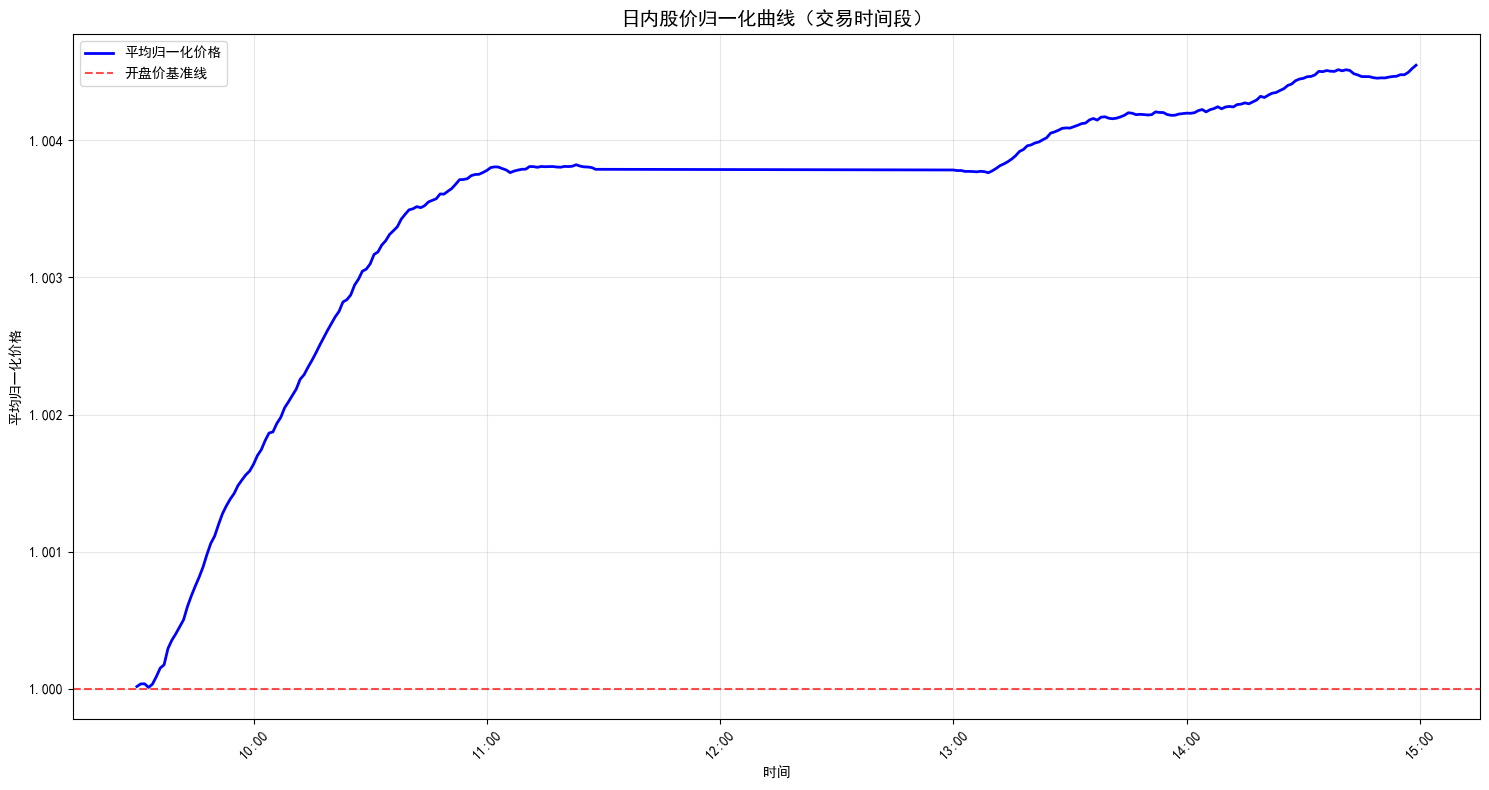


📊 统计信息:
   总股票数: 500
   总数据点: 21675174
   平均每只股票数据点: 43350.3
   平均价格范围: 1.0000 - 1.0045
   最高平均价格时间: 14:59
   最低平均价格时间: 09:33
✅ 日内股价折线图绘制完成！


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 使用已有的股票池
print(f"📊 使用筛选后的股票池，数量: {len(stock_codes)}")

# 设置时间范围和参数
start_date = "2025-01-02 09:30:00"
end_date = "2025-09-30 15:00:00"
max_stocks = 500

print(f"📈 开始获取 {max_stocks} 只股票的日内价格数据...")

# 获取数据并归一化
all_data = []
valid_stocks = []

for i, stock in enumerate(stock_codes[:max_stocks]):
    try:
        print(f"🔍 处理 {stock} ({i+1}/{max_stocks})...")
        
        # 获取分钟数据
        df = D.features([stock], ["$open", "$close"], start_time=start_date, end_time=end_date, freq="1min")
        
        if df is None or df.empty:
            continue
            
        if isinstance(df.index, pd.MultiIndex):
            df = df.xs(stock, level='instrument', drop_level=True)
        
        if df.empty:
            continue
        
        # 按日期处理
        df.index = pd.to_datetime(df.index)
        for date, day_df in df.groupby(df.index.date):
            if len(day_df) < 10:
                continue

            # 获取开盘价并归一化
            open_price = day_df['$open'].replace(0, np.nan).dropna()
            if len(open_price) == 0 or open_price.iloc[0] <= 0:
                continue
                
            first_open = open_price.iloc[0]
            normalized_close = day_df['$close'] / first_open
            
            # 保存数据
            day_data = pd.DataFrame({
                'time': day_df.index,
                'normalized_price': normalized_close,
                'stock': stock
            })
            all_data.append(day_data)
        
        valid_stocks.append(stock)
        print(f"✅ {stock}: 成功")
        
    except Exception as e:
        print(f"❌ {stock}: 失败 - {e}")
        continue

if not all_data:
    print("❌ 没有获取到任何有效数据")
else:
    # 合并数据
    combined_data = pd.concat(all_data, ignore_index=True)
    print(f"📊 获取到 {len(combined_data)} 个数据点，来自 {len(valid_stocks)} 只股票")
    
    # 计算平均模式
    combined_data['time_of_day'] = combined_data['time'].dt.hour * 60 + combined_data['time'].dt.minute
    avg_pattern = combined_data.groupby('time_of_day')['normalized_price'].agg(['mean', 'std', 'count']).reset_index()
    avg_pattern['time_str'] = avg_pattern['time_of_day'].apply(lambda x: f"{x//60:02d}:{x%60:02d}")
    avg_pattern = avg_pattern[avg_pattern['count'] >= 5]
    
    # 只显示交易时间段（9:30-11:30 和 13:00-15:00）
    trading_hours = avg_pattern[
        ((avg_pattern['time_of_day'] >= 9*60+30) & (avg_pattern['time_of_day'] <= 11*60+30)) |
        ((avg_pattern['time_of_day'] >= 13*60) & (avg_pattern['time_of_day'] <= 15*60))
    ].copy()
    
    # 绘制图形（只显示平均价格模式）
    fig, ax = plt.subplots(1, 1, figsize=(15, 8))
    
    # 只显示平均价格折线
    if len(trading_hours) > 0:
        time_axis = pd.to_datetime(trading_hours['time_str'], format='%H:%M')
        ax.plot(time_axis, trading_hours['mean'], 'b-', linewidth=2, label='平均归一化价格')
        
        ax.set_title('日内股价归一化曲线（交易时间段）', fontsize=14, fontweight='bold')
        ax.set_xlabel('时间')
        ax.set_ylabel('平均归一化价格')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='开盘价基准线')
        ax.legend()
        
        # 设置x轴格式
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # 统计信息
    print(f"\n📊 统计信息:")
    print(f"   总股票数: {len(combined_data['stock'].unique())}")
    print(f"   总数据点: {len(combined_data)}")
    print(f"   平均每只股票数据点: {len(combined_data) / len(combined_data['stock'].unique()):.1f}")
    
    if len(trading_hours) > 0:
        print(f"   平均价格范围: {trading_hours['mean'].min():.4f} - {trading_hours['mean'].max():.4f}")
        print(f"   最高平均价格时间: {trading_hours.loc[trading_hours['mean'].idxmax(), 'time_str']}")
        print(f"   最低平均价格时间: {trading_hours.loc[trading_hours['mean'].idxmin(), 'time_str']}")
    
    print("✅ 日内股价折线图绘制完成！")

构建 dataset_task 和 model_task

In [6]:
#训练
from qlib.workflow import R
from qlib.utils import init_instance_by_config
from qlib.contrib.model.gbdt import LGBModel
import pandas as pd


# dataset task
dataset_task = {
    "class": "DatasetH",
    "module_path": "qlib.data.dataset",
    "kwargs": {
        "handler": {
            "class": "HighFreqHandler",   ## 使用我们修改过的 handler
            "module_path": "highfreq_handler",
            "kwargs": handler_config,
        },
        "segments": {
            "train": (wf.start_time, wf.train_end_time),
            "test": (wf.test_start_time, wf.end_time),
        },
        #"infer_processors": handler_config["infer_processors"],
        #"learn_processors": handler_config["infer_processors"],
        
    },
}


handler_cfg = dataset_task['kwargs']['handler']


# 修正时间段 和自定义数据时间段一致 否则会用默认路径时间 重要！！！
handler_cfg['kwargs'].update({
    'start_time': '2025-01-02 09:30:00',
    'end_time': '2025-10-27 14:57:00',
    'fit_start_time': '2025-01-02 09:30:00',
    'fit_end_time': '2025-07-15 14:57:00'
})

dataset_task['kwargs']['handler'] = handler_cfg

# 模型 task
model_task = {
    "class": "LGBModel",
    "module_path": "qlib.contrib.model.gbdt",
    "kwargs": {
        "loss": "mse",
        "learning_rate": 0.1,
        "n_estimators": 100,
        "num_leaves": 31,
        "min_child_samples": 20,    # 增加最小样本数
        "reg_alpha": 0.1,           # 添加L1正则化
        "reg_lambda": 0.1,          # 添加L2正则化
    },
}

# 整体 task
task = {
    "dataset": dataset_task,
    "model": model_task,
}


实例化handler 筛选训练时间段覆盖率≥95%的标的

In [7]:
from qlib.utils import init_instance_by_config

handler = init_instance_by_config(handler_cfg)

[12292:MainThread](2025-10-29 20:44:43,410) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [DayLast] will override the qlib default definition
[12292:MainThread](2025-10-29 20:44:43,412) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [FFillNan] will override the qlib default definition
[12292:MainThread](2025-10-29 20:44:43,413) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [Date] will override the qlib default definition
[12292:MainThread](2025-10-29 20:44:43,414) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [Select] will override the qlib default definition
[12292:MainThread](2025-10-29 20:44:43,415) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [IsNull] will override the qlib default definition
[12292:MainThread](2025-10-29 20:44:43,416) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [Cut] will override the qlib default definition
[12292:MainThread](2025-10-29 20:44:43,417) WARN

[12292:MainThread](2025-10-29 20:44:43,417) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [IntradayWindowVWAP] will override the qlib default definition
[12292:MainThread](2025-10-29 20:44:43,419) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [DayShift] will override the qlib default definition
[12292:MainThread](2025-10-29 20:44:43,420) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [If] will override the qlib default definition


ValueError: Can only compare identically-labeled Series objects. 
	Loading SH600592: Gt(Div(Add(Add(Add(FFillNan(Select(Or(IsNull($paused),Eq($paused,0.0)),$open)),Mul(FFillNan(Select(Or(IsNull($paused),Eq($paused,0.0)),$high)),2)),Mul(FFillNan(Select(Or(IsNull($paused),Eq($paused,0.0)),$low)),2)),FFillNan(Select(Or(IsNull($paused),Eq($paused,0.0)),$close))),6),Mul(1.001,FFillNan(Select(Or(IsNull($paused),Eq($paused,0.0)),$high)))); np.greater(series_left, series_right), The length of series_left and series_right is different: (47029, 47028), series_left is Div(Add(Add(Add(FFillNan(Select(Or(IsNull($paused),Eq($paused,0.0)),$open)),Mul(FFillNan(Select(Or(IsNull($paused),Eq($paused,0.0)),$high)),2)),Mul(FFillNan(Select(Or(IsNull($paused),Eq($paused,0.0)),$low)),2)),FFillNan(Select(Or(IsNull($paused),Eq($paused,0.0)),$close))),6), series_right is Mul(1.001,FFillNan(Select(Or(IsNull($paused),Eq($paused,0.0)),$high))). Please check the data

In [8]:
from qlib.data.dataset import DatasetH

# 用同一个 handler，构造一个只含训练段的临时 DatasetH（很快）
tmp_dataset = DatasetH(
    handler=handler,
    segments={'train': (START_TIME, TRAIN_END_TIME)},
)

# 只取训练期的 label
train_df = tmp_dataset.prepare(['train'], col_set=['label'])[0]['label']
labels = train_df[[c for c in train_df.columns if str(c).upper().startswith('LABEL')][0]]

import pandas as pd
import numpy as np
import pickle
from pathlib import Path

df = labels.reset_index()
df['date'] = pd.to_datetime(df['datetime']).dt.date
per_day_cnt = df.groupby(['instrument', 'date'])[labels.name].apply(lambda s: s.notna().sum())
total_days = len(sorted(df['date'].unique()))
valid_days = (per_day_cnt == 240).groupby('instrument').sum()
coverage = (valid_days / float(total_days)).fillna(0.0)

stock_codes = coverage[coverage >= 0.95].index.tolist()
Path('filtered_market.pkl').write_bytes(pickle.dumps(stock_codes))
print(f'覆盖率≥95%的标的数: {len(stock_codes)} / 全部: {coverage.shape[0]}')
print('✅ 筛选结果已保存 -> filtered_market.pkl')

NameError: name 'handler' is not defined

实例化数据集（这时候 dataset_task 已经定义）

In [9]:

from qlib.utils import init_instance_by_config


dataset = init_instance_by_config(dataset_task)

[35200:MainThread](2025-10-29 17:51:55,492) INFO - qlib.timer - [log.py:127] - Time cost: 74.802s | Loading data Done
[35200:MainThread](2025-10-29 17:52:03,548) INFO - qlib.timer - [log.py:127] - Time cost: 7.168s | HighFreqNorm Done
[35200:MainThread](2025-10-29 17:52:03,750) INFO - qlib.timer - [log.py:127] - Time cost: 8.257s | fit & process data Done


父类setup_data后，_data属性不存在！
尝试手动设置_data属性...


[35200:MainThread](2025-10-29 17:54:51,932) INFO - qlib.timer - [log.py:127] - Time cost: 251.242s | Init data Done


In [13]:
# 1) 强制把筛后的股票写回 handler
if hasattr(handler, 'set_instruments'):
    handler.set_instruments(stock_codes)
else:
    handler.instruments = stock_codes  # 大多数 DataHandler 支持直接覆盖

# 2) 清理 handler 的缓存数据，避免沿用旧全集数据
for buf in ['_data','_learn','_infer','_data_l','_data_i']:
    if hasattr(handler, buf):
        setattr(handler, buf, None)

# 3) 重新加载（只一次）
handler.setup_data()

# 4) 用同一个 handler 构造 dataset（新变量名，避免被旧 dataset 覆盖）
from qlib.data.dataset import DatasetH
segments = dataset_task["kwargs"]["segments"]
other_kwargs = {k: v for k, v in dataset_task["kwargs"].items() if k not in ("handler","instruments","segments")}

dataset_clean = DatasetH(handler=handler, instruments=stock_codes, segments=segments, **other_kwargs)

# 5) 再次核验
pack = dataset_clean.prepare(['train'], col_set=['label'])[0]
lbl  = pack['label']['LABEL0']
inst_in_dataset = pd.Index(lbl.index.get_level_values('instrument')).unique()
print('len(inst_in_dataset)=', len(inst_in_dataset))  # 应≈len(stock_codes)

_data 形状: None


[35200:MainThread](2025-10-29 17:55:47,060) INFO - qlib.timer - [log.py:127] - Time cost: 0.005s | Loading data Done
[35200:MainThread](2025-10-29 17:55:47,063) INFO - qlib.timer - [log.py:127] - Time cost: 0.001s | HighFreqNorm Done
[35200:MainThread](2025-10-29 17:55:47,065) INFO - qlib.timer - [log.py:127] - Time cost: 0.003s | fit & process data Done


父类setup_data后，_data属性不存在！
尝试手动设置_data属性...
len(inst_in_dataset)= 0


In [14]:
# 检查 dataset_clean 实际包含的股票集合
pack = dataset_clean.prepare(['train'], col_set=['label'])[0]
lbl = pack['label']['LABEL0']
inst_in_dataset = pd.Index(lbl.index.get_level_values('instrument')).unique()

print('len(stock_codes)=', len(stock_codes))
print('len(inst_in_dataset)=', len(inst_in_dataset))
print('unexpected (in dataset but not in stock_codes):', 
      sorted(set(inst_in_dataset) - set(stock_codes))[:10])
print('missing (in stock_codes but not in dataset):', 
      sorted(set(stock_codes) - set(inst_in_dataset))[:10])

len(stock_codes)= 0
len(inst_in_dataset)= 0
unexpected (in dataset but not in stock_codes): []
missing (in stock_codes but not in dataset): []


In [15]:
from qlib.data.dataset.handler import DataHandlerLP
train_df = dataset_clean.prepare("train", col_set=["feature", "label"], data_key=DataHandlerLP.DK_L)
xtrain = train_df["feature"]
ytrain = train_df["label"]

test_df = dataset_clean.prepare("test", col_set=["feature", "label"], data_key=DataHandlerLP.DK_I)
xtest = test_df["feature"]
ytest = test_df["label"]

if xtrain.size == 0 or xtest.size == 0:
    raise ValueError("❌ 数据为空！请检查股票池与 provider_uri 是否匹配天勤数据")
else:
    print(f"✅ 数据检查通过: 训练集 {xtrain.shape}, 测试集 {xtest.shape}")

print("训练集:", xtrain.shape, ytrain.shape)
print("样本预览:")
print(xtrain.head(300))
print(xtest.head(300))

ValueError: ❌ 数据为空！请检查股票池与 provider_uri 是否匹配天勤数据

In [12]:
ytest.head(350)

LABEL0
instrument datetime                     
SH000300   2025-07-16 09:30:00  0.002521
           2025-07-16 09:31:00  0.002521
           2025-07-16 09:32:00  0.002521
           2025-07-16 09:33:00  0.002521
           2025-07-16 09:34:00  0.002521
...                                  ...
           2025-07-17 11:15:00  0.006614
           2025-07-17 11:16:00  0.006614
           2025-07-17 11:17:00  0.006614
           2025-07-17 11:18:00  0.006614
           2025-07-17 11:19:00  0.006614

[350 rows x 1 columns]

In [13]:
ytrain.head(300)

LABEL0
instrument datetime                     
SH000300   2025-01-02 09:30:00  0.002929
           2025-01-02 09:31:00  0.002929
           2025-01-02 09:32:00  0.002929
           2025-01-02 09:33:00  0.002929
           2025-01-02 09:34:00  0.002929
...                                  ...
           2025-01-03 10:25:00 -0.001419
           2025-01-03 10:26:00 -0.001419
           2025-01-03 10:27:00 -0.001419
           2025-01-03 10:28:00 -0.001419
           2025-01-03 10:29:00 -0.001419

[300 rows x 1 columns]

label柱状图巡检

🔍 开始分析修正后的label分布（强制使用筛后股票池）...
📊 Handler类型: <class 'highfreq_handler.HighFreqHandler'>
_data 形状: None


[36020:MainThread](2025-10-29 12:32:50,786) INFO - qlib.timer - [log.py:127] - Time cost: 39.191s | Loading data Done
c:\Users\ASUS\qlib\examples\highfreq\highfreq_processor.py:47: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(values)
c:\Users\ASUS\qlib\examples\highfreq\highfreq_processor.py:48: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(values - med)) * 1.4826 + EPS
c:\Users\ASUS\qlib\examples\highfreq\highfreq_processor.py:55: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(scaled)
c:\Users\ASUS\qlib\examples\highfreq\highfreq_processor.py:56: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(scaled)
[36020:MainThread](2025-10-29 12:32:56,077) INFO - qlib.timer - [log.py:127] - Time cost: 3.891s | HighFreqNorm Done
[36020:MainThread](2025-10-29 12:32:56,230) INFO - qlib.timer - [log.py:127] - Time cost: 5.443s | fit & process data Done


父类setup_data后，_data属性不存在！
尝试手动设置_data属性...
✅ 已强制切换到筛后股票池: 475 支
📊 正在获取label数据（自定义标签）...
📊 获取到label数据形状: (21509478, 1)
📊 数据索引类型: <class 'pandas.core.indexes.multi.MultiIndex'>
📊 数据列名: ['LABEL0']
📊 总label数量: 20743690
📊 NaN值数量: 113050
📊 有效label数量: 20630640

🔍 检查第一天label值...
   第一个label值: 0.0029291378672131607
⚠️ 第一天不为NaN，可能label顺延有问题

📊 有效label统计信息:
   均值: 0.004027
   标准差: 0.033224
   最小值: -0.199982
   最大值: 0.203272
📊 日度label数量: 182


C:\Users\ASUS\AppData\Local\Temp\ipykernel_36020\2249016017.py:122: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot([valid_labels.values], labels=['修正后Label'])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_36020\2249016017.py:128: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_36020\2249016017.py:128: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_36020\2249016017.py:128: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_36020\2249016017.py:128: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  

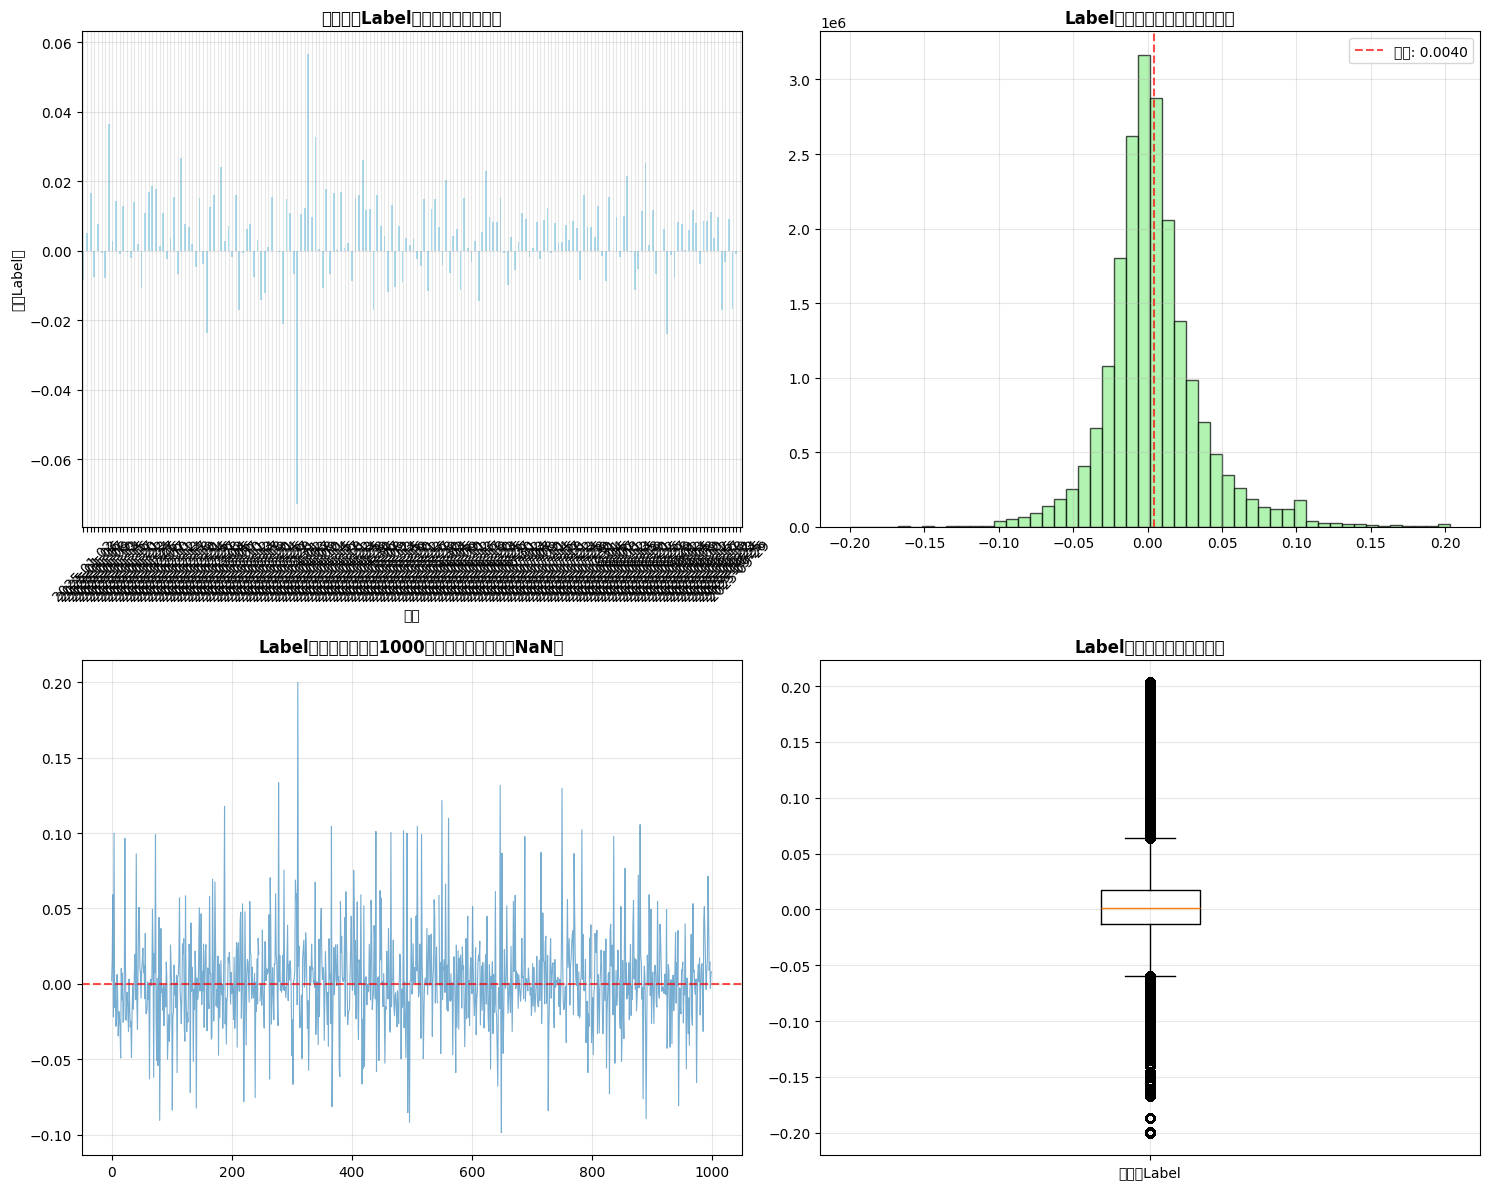


📊 异常值分析:
   异常值数量: 1500480 (7.27%)

📊 备注：本分析强制使用筛后股票池，避免使用旧 dataset 的全市场股票。


In [13]:
def plot_label_analysis(dataset_clean, start_time, end_time, stock_codes):
    """
    分析修正后的label分布 - 强制使用 dataset_clean + stock_codes
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    print("🔍 开始分析修正后的label分布（强制使用筛后股票池）...")

    # 1) 从 dataset_clean 获取 handler
    handler = dataset_clean.handler
    print(f"📊 Handler类型: {type(handler)}")

    # 2) 强制将筛后的股票写回 handler
    try:
        if hasattr(handler, "set_instruments"):
            handler.set_instruments(stock_codes)
        else:
            handler.instruments = stock_codes
        # 清理 handler 可能的缓存，避免沿用旧全集数据
        for buf in ['_data','_learn','_infer','_data_l','_data_i']:
            if hasattr(handler, buf):
                setattr(handler, buf, None)
        # 重新加载（只一次）
        handler.setup_data()
        print(f"✅ 已强制切换到筛后股票池: {len(stock_codes)} 支")
    except Exception as e:
        print(f"⚠️ 切换股票池失败，继续尝试按传入股票池取数: {e}")

    # 3) 用筛后的股票池拉取 label（直接调你的自定义标签生成）
    try:
        print("📊 正在获取label数据（自定义标签）...")
        label_data = handler._load_custom_labels(stock_codes, start_time, end_time)

        if label_data is None or label_data.empty:
            print("❌ 无法获取label数据")
            return

        print(f"📊 获取到label数据形状: {label_data.shape}")
        print(f"📊 数据索引类型: {type(label_data.index)}")
        print(f"📊 数据列名: {label_data.columns.tolist()}")
        
        # 仅保留传入的 stock_codes（双保险）
        if isinstance(label_data.index, pd.MultiIndex):
            inst_level = 'instrument' if 'instrument' in label_data.index.names else label_data.index.names[0]
            label_data = label_data[label_data.index.get_level_values(inst_level).isin(stock_codes)]

        # 提取label值（不dropna，保留NaN）
        labels = label_data['LABEL0'] if 'LABEL0' in label_data.columns else label_data.iloc[:, 0]
        print(f"📊 总label数量: {len(labels)}")
        print(f"📊 NaN值数量: {labels.isna().sum()}")
        print(f"📊 有效label数量: {labels.notna().sum()}")

        # 检查第一天是否为NaN
        print("\n🔍 检查第一天label值...")
        first_label = labels.iloc[0]
        print(f"   第一个label值: {first_label}")
        if pd.isna(first_label):
            print("✅ 第一天为NaN，说明label已正确顺延到次日")
        else:
            print("⚠️ 第一天不为NaN，可能label顺延有问题")

        # 统计信息（只对非NaN值）
        valid_labels = labels.dropna()
        if len(valid_labels) > 0:
            print(f"\n📊 有效label统计信息:")
            print(f"   均值: {valid_labels.mean():.6f}")
            print(f"   标准差: {valid_labels.std():.6f}")
            print(f"   最小值: {valid_labels.min():.6f}")
            print(f"   最大值: {valid_labels.max():.6f}")

        # 日度聚合（与 MultiIndex 兼容）
        daily_labels = None
        if isinstance(label_data.index, pd.MultiIndex):
            datetime_index = label_data.index.get_level_values('datetime') if 'datetime' in label_data.index.names else label_data.index.get_level_values(-1)
            dates = pd.to_datetime(datetime_index).date
            daily_labels = pd.Series(labels.values, index=dates).groupby(level=0).mean()
            print(f"📊 日度label数量: {len(daily_labels)}")
        else:
            dates = pd.to_datetime(label_data.index).date
            daily_labels = pd.Series(labels.values, index=dates).groupby(level=0).mean()
            print(f"📊 日度label数量（单层索引）: {len(daily_labels)}")

        # 绘图
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
        
        # 图1: 日度平均label柱状图
        if daily_labels is not None and len(daily_labels) > 0:
            daily_labels.plot(kind='bar', ax=ax1, color='skyblue', alpha=0.7)
            ax1.set_title('日度平均Label分布（筛后股票池）', fontsize=12, fontweight='bold')
            ax1.set_xlabel('日期')
            ax1.set_ylabel('平均Label值')
            ax1.tick_params(axis='x', rotation=45)
            ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, '无法提取日度数据', ha='center', va='center', transform=ax1.transAxes)

        # 图2: Label分布直方图（只对有效值）
        if len(valid_labels) > 0:
            ax2.hist(valid_labels, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
            ax2.set_title('Label分布直方图（筛后股票池）', fontsize=12, fontweight='bold')
            ax2.axvline(valid_labels.mean(), color='red', linestyle='--', alpha=0.7, label=f'均值: {valid_labels.mean():.4f}')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, '没有有效数据', ha='center', va='center', transform=ax2.transAxes)

        # 图3: Label时间序列（采样显示，包含NaN）
        if len(labels) > 1000:
            sample_labels = labels.sample(1000).sort_index()
            ax3.plot(range(len(sample_labels)), sample_labels.values, alpha=0.6, linewidth=0.8)
            ax3.set_title('Label时间序列（采样1000点，筛后股票池，含NaN）', fontsize=12, fontweight='bold')
        else:
            ax3.plot(range(len(labels)), labels.values, alpha=0.6, linewidth=0.8)
            ax3.set_title('Label时间序列（全部数据，筛后股票池，含NaN）', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3)
        ax3.axhline(0, color='red', linestyle='--', alpha=0.7)

        # 图4: Label箱线图（只对有效值）
        if len(valid_labels) > 0:
            ax4.boxplot([valid_labels.values], labels=['修正后Label'])
            ax4.set_title('Label箱线图（筛后股票池）', fontsize=12, fontweight='bold')
            ax4.grid(True, alpha=0.3)
        else:
            ax4.text(0.5, 0.5, '没有有效数据', ha='center', va='center', transform=ax4.transAxes)

        plt.tight_layout()
        plt.show()
        
        # 异常值分析（只对有效值）
        if len(valid_labels) > 0:
            print("\n📊 异常值分析:")
            q1 = valid_labels.quantile(0.25)
            q3 = valid_labels.quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            outliers = valid_labels[(valid_labels < lower_bound) | (valid_labels > upper_bound)]
            print(f"   异常值数量: {len(outliers)} ({len(outliers)/len(valid_labels)*100:.2f}%)")

        print("\n📊 备注：本分析强制使用筛后股票池，避免使用旧 dataset 的全市场股票。")

    except Exception as e:
        print(f"❌ 分析失败: {e}")
        import traceback
        traceback.print_exc()

plot_label_analysis(dataset_clean, START_TIME, END_TIME, stock_codes)

In [14]:
ytrain.head(400)

LABEL0
instrument datetime                     
SH000300   2025-01-02 09:30:00  0.002929
           2025-01-02 09:31:00  0.002929
           2025-01-02 09:32:00  0.002929
           2025-01-02 09:33:00  0.002929
           2025-01-02 09:34:00  0.002929
...                                  ...
           2025-01-03 13:35:00 -0.001419
           2025-01-03 13:36:00 -0.001419
           2025-01-03 13:37:00 -0.001419
           2025-01-03 13:38:00 -0.001419
           2025-01-03 13:39:00 -0.001419

[400 rows x 1 columns]

In [15]:
# 5. 检查标签数据质量
print("\n标签数据质量:")
print("ytrain 统计:", ytrain["LABEL0"].describe())
print("ytrain 唯一值数量:", ytrain["LABEL0"].nunique())
print("ytrain 是否全为0:", (ytrain["LABEL0"] == 0).all())
print("ytest 统计:", ytest["LABEL0"].describe())


标签数据质量:
ytrain 统计: count    1.458864e+07
mean     4.258421e-03
std      3.345582e-02
min     -1.999824e-01
25%     -1.290344e-02
50%      1.408399e-03
75%      1.786281e-02
max      2.032722e-01
Name: LABEL0, dtype: float64
ytrain 唯一值数量: 60036
ytrain 是否全为0: False
ytest 统计: count    6.042000e+06
mean     3.468288e-03
std      3.265015e-02
min     -1.351720e-01
25%     -1.425899e-02
50%      3.542594e-05
75%      1.641667e-02
max      2.026142e-01
Name: LABEL0, dtype: float64


训练

In [16]:

from qlib.utils import init_instance_by_config

#dataset = init_instance_by_config(task["dataset"])
model = init_instance_by_config(task["model"])
recorder = R.get_recorder()
# 开始训练
model.fit(dataset_clean)

# 保存模型
R.save_objects(model=model)

print("✅ 模型训练完成")


[36020:MainThread](2025-10-29 12:50:03,607) WARNING - qlib.workflow - [exp.py:308] - Please make sure the recorder name mlflow_recorder is unique, we will only return the latest recorder if there exist several matched the given name.
c:\Users\ASUS\miniconda3\Lib\site-packages\lightgbm\callback.py:347: UserWarning: Only training set found, disabling early stopping.
  _log_warning("Only training set found, disabling early stopping.")


[20]	train's l2: 0.00111929
[40]	train's l2: 0.00111929
[60]	train's l2: 0.00111929
[80]	train's l2: 0.00111929
[100]	train's l2: 0.00111929


[36020:MainThread](2025-10-29 12:50:10,944) INFO - qlib.workflow - [exp.py:258] - Experiment 163818717121484802 starts running ...
[36020:MainThread](2025-10-29 12:50:11,095) INFO - qlib.workflow - [recorder.py:345] - Recorder 616bf24d323b477ba62f1f316ef76fb2 starts running under Experiment 163818717121484802 ...


✅ 模型训练完成


信号

In [17]:
#生成信号并记录
from qlib.workflow import R
from qlib.workflow.record_temp import SignalRecord, PortAnaRecord
from qlib.contrib.strategy.signal_strategy import TopkDropoutStrategy
from qlib.contrib.evaluate import risk_analysis

# 开启一次简单实验记录 不覆盖之前
R.start(experiment_name="HF_MIN_BACKTEST", recorder_name="recorder")
recorder = R.get_recorder()

# 将模型在 dataset 上的预测保存为信号
sr = SignalRecord(model, dataset_clean, recorder)
sr.generate()

[36020:MainThread](2025-10-29 12:50:14,380) INFO - qlib.workflow - [record_temp.py:198] - Signal record 'pred.pkl' has been saved as the artifact of the Experiment 163818717121484802


'The following are prediction results of the LGBModel model.'
                                   score
instrument datetime                     
SH000300   2025-07-16 09:30:00  0.004258
           2025-07-16 09:31:00  0.004258
           2025-07-16 09:32:00  0.004258
           2025-07-16 09:33:00  0.004258
           2025-07-16 09:34:00  0.004258


[36020:MainThread](2025-10-29 12:50:14,385) WARNING - qlib.workflow - [record_temp.py:187] - Exception: DataHandlerLP has not attribute _data, please set drop_raw = False if you want to use raw data


In [18]:
pred = model.predict(dataset_clean)
test_df = dataset_clean.prepare(['test'], col_set=['label'])
labels = test_df[0]['label']['LABEL0']

print(pred.head(100))

instrument  datetime           
SH000300    2025-07-16 09:30:00    0.004258
            2025-07-16 09:31:00    0.004258
            2025-07-16 09:32:00    0.004258
            2025-07-16 09:33:00    0.004258
            2025-07-16 09:34:00    0.004258
                                     ...   
            2025-07-16 11:05:00    0.004258
            2025-07-16 11:06:00    0.004258
            2025-07-16 11:07:00    0.004258
            2025-07-16 11:08:00    0.004258
            2025-07-16 11:09:00    0.004258
Length: 100, dtype: float64


In [19]:
print(f"NaN 数量: {pred.isna().sum()}, 占比: {pred.isna().mean():.2%}, 总数: {len(pred)}")

print(pred.head(400))
pred.describe()

NaN 数量: 0, 占比: 0.00%, 总数: 6155050
instrument  datetime           
SH000300    2025-07-16 09:30:00    0.004258
            2025-07-16 09:31:00    0.004258
            2025-07-16 09:32:00    0.004258
            2025-07-16 09:33:00    0.004258
            2025-07-16 09:34:00    0.004258
                                     ...   
            2025-07-17 13:35:00    0.004258
            2025-07-17 13:36:00    0.004258
            2025-07-17 13:37:00    0.004258
            2025-07-17 13:38:00    0.004258
            2025-07-17 13:39:00    0.004258
Length: 400, dtype: float64


count    6.155050e+06
mean     4.258421e-03
std      8.673618e-19
min      4.258421e-03
25%      4.258421e-03
50%      4.258421e-03
75%      4.258421e-03
max      4.258421e-03
dtype: float64

In [20]:
print(f"NaN 数量: {labels.isna().sum()}, 占比: {labels.isna().mean():.2%}, 总数: {len(labels)}")

print(labels.head(300))

NaN 数量: 113050, 占比: 1.84%, 总数: 6155050
instrument  datetime           
SH000300    2025-07-16 09:30:00    0.002521
            2025-07-16 09:31:00    0.002521
            2025-07-16 09:32:00    0.002521
            2025-07-16 09:33:00    0.002521
            2025-07-16 09:34:00    0.002521
                                     ...   
            2025-07-17 10:25:00    0.006614
            2025-07-17 10:26:00    0.006614
            2025-07-17 10:27:00    0.006614
            2025-07-17 10:28:00    0.006614
            2025-07-17 10:29:00    0.006614
Name: LABEL0, Length: 300, dtype: float64


pred稳健化 去极端值

In [15]:
# 修复后的代码：
import numpy as np
import pandas as pd

# 处理DataFrame格式的pred
if isinstance(pred, pd.DataFrame):
    # 如果是DataFrame，取第一列
    s = pred.iloc[:, 0]
else:
    s = pred

# 保证是Series
if not isinstance(s, pd.Series):
    s = pd.Series(s)

# 现在进行rank化
if isinstance(s.index, pd.MultiIndex) and "datetime" in s.index.names:
    pred_ranked = s.groupby(level="datetime", group_keys=False).rank(pct=True) * 2 - 1
else:
    pred_ranked = s.rank(pct=True) * 2 - 1

pred_processed = pred_ranked

# 验证rank化是否生效
print("原始pred统计:")
print(s.describe())
print("\nRank化后统计:")
print(pred_processed.describe())
print(f"\n是否相同: {np.allclose(s, pred_processed)}")  # 应该为False

原始pred统计:
count    6.155050e+06
mean     4.414611e-03
std      5.371597e-03
min     -8.729671e-02
25%      2.773488e-03
50%      3.879614e-03
75%      5.041740e-03
max      1.566117e-01
dtype: float64

Rank化后统计:
count    6.155050e+06
mean     2.105263e-03
std      5.773462e-01
min     -9.957895e-01
25%     -4.989474e-01
50%      2.105263e-03
75%      5.031579e-01
max      1.000000e+00
dtype: float64

是否相同: False


信号生成 用pred_processed

In [16]:
# 2) 再用处理后的pred生成信号
from qlib.workflow import R
from qlib.workflow.record_temp import SignalRecord

# 开启实验记录
R.start(experiment_name="HF_MIN_BACKTEST", recorder_name="recorder")
recorder = R.get_recorder()

# 方法1：直接用recorder保存处理后的信号
recorder.save_objects(**{"pred.pkl": pred_processed})
print("✅ 已保存稳健处理后的信号")

✅ 已保存稳健处理后的信号


IC分析 日频 周频

调用qlib官方函数 最最最正确的一版

In [17]:
from qlib.contrib.eva.alpha import calc_ic

pred_label = pd.DataFrame({
    'label': labels,
    'score': pred_processed
})

# 计算IC
ic, rank_ic = calc_ic(
    pred=pred_label['score'], 
    label=pred_label['label'], 
    date_col="datetime", 
    dropna=True
)

print("IC结果:")
print(f"IC均值: {ic.mean():.4f}")
print(f"IC标准差: {ic.std():.4f}")
print(f"Rank IC均值: {rank_ic.mean():.4f}")
print(f"Rank IC标准差: {rank_ic.std():.4f}")

# 查看IC时间序列
print("\nIC时间序列:")
print(ic.head())
print(ic.tail())


IC结果:
IC均值: 0.0408
IC标准差: 0.0658
Rank IC均值: 0.0143
Rank IC标准差: 0.0742

IC时间序列:
datetime
2025-07-16 09:30:00    0.039826
2025-07-16 09:31:00    0.015193
2025-07-16 09:32:00    0.022080
2025-07-16 09:33:00    0.050491
2025-07-16 09:34:00    0.031571
dtype: float64
datetime
2025-09-26 14:55:00    0.048089
2025-09-26 14:56:00    0.015817
2025-09-26 14:57:00    0.001077
2025-09-26 14:58:00   -0.021009
2025-09-26 14:59:00    0.086216
dtype: float64


IC结果:
IC均值: 0.0414
IC标准差: 0.0652
Rank IC均值: 0.0158
Rank IC标准差: 0.0729


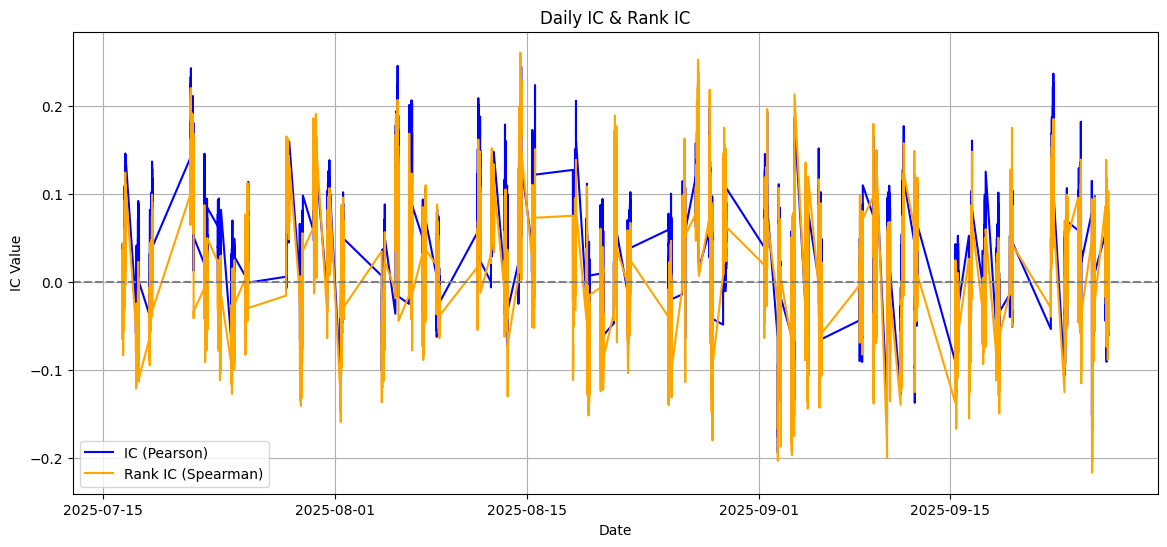

In [23]:
import matplotlib.pyplot as plt
# 打印结果
print("IC结果:")
print(f"IC均值: {ic.mean():.4f}")
print(f"IC标准差: {ic.std():.4f}")
print(f"Rank IC均值: {rank_ic.mean():.4f}")
print(f"Rank IC标准差: {rank_ic.std():.4f}")

# 可视化 IC 和 Rank IC
plt.figure(figsize=(14,6))
plt.plot(ic.index, ic, label="IC (Pearson)", color="blue")
plt.plot(rank_ic.index, rank_ic, label="Rank IC (Spearman)", color="orange")
plt.axhline(0, color='gray', linestyle='--')
plt.title("Daily IC & Rank IC")
plt.xlabel("Date")
plt.ylabel("IC Value")
plt.legend()
plt.grid(True)
plt.show()


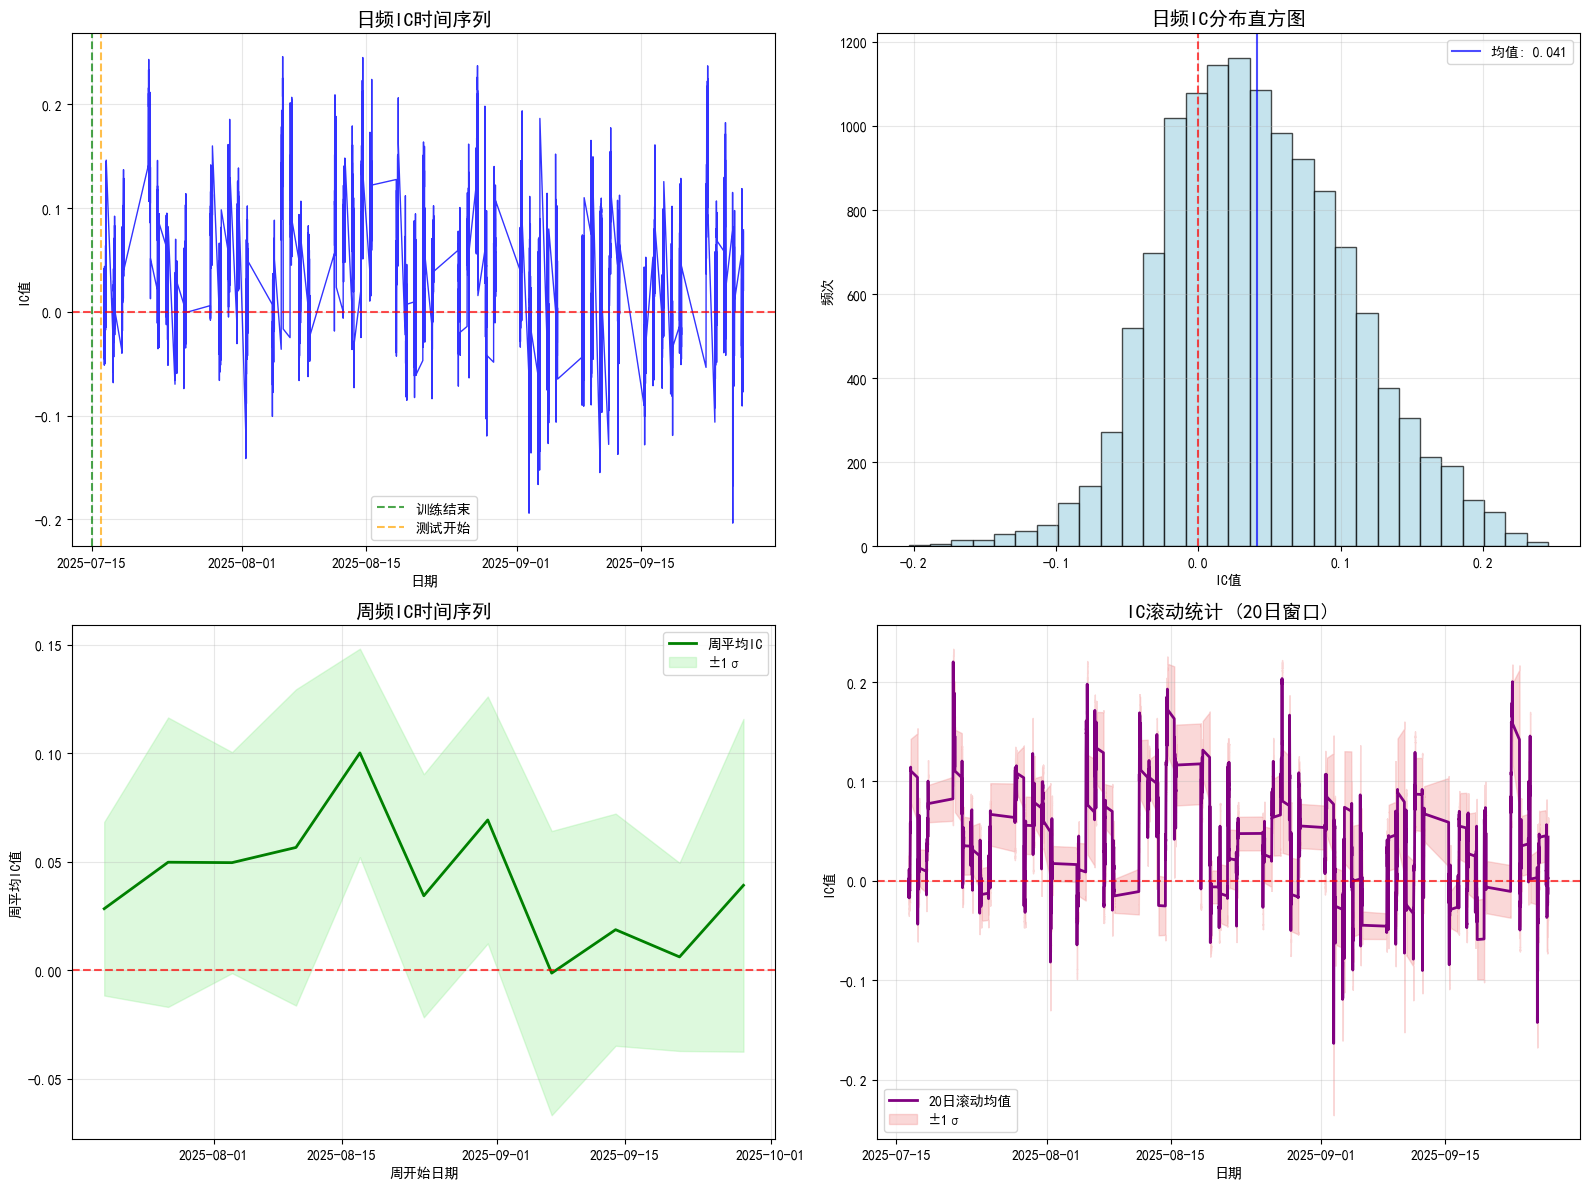


📊 IC统计摘要:
日频IC均值: 0.0414
日频IC标准差: 0.0652
日频IC胜率: 72.43%
Rank IC均值: 0.0158
Rank IC标准差: 0.0729
Rank IC胜率: 55.67%

测试期IC统计:
  均值: 0.0414
  标准差: 0.0652
  胜率: 72.43%


In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 创建2x2子图
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. 日频IC时间序列
ax1.plot(ic.index, ic.values, 'b-', linewidth=1, alpha=0.8)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax1.set_title('日频IC时间序列', fontsize=14, fontweight='bold')
ax1.set_xlabel('日期')
ax1.set_ylabel('IC值')
ax1.grid(True, alpha=0.3)

# 添加训练结束和测试开始标记
train_end = datetime(2025, 7, 15)  # 根据你的实际训练结束时间调整
test_start = datetime(2025, 7, 16)  # 根据你的实际测试开始时间调整
ax1.axvline(x=train_end, color='green', linestyle='--', alpha=0.7, label='训练结束')
ax1.axvline(x=test_start, color='orange', linestyle='--', alpha=0.7, label='测试开始')
ax1.legend()

# 2. 日频IC分布直方图
ax2.hist(ic.values, bins=30, alpha=0.7, color='lightblue', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.7)
ax2.axvline(x=ic.mean(), color='blue', linestyle='-', alpha=0.7, label=f'均值: {ic.mean():.3f}')
ax2.set_title('日频IC分布直方图', fontsize=14, fontweight='bold')
ax2.set_xlabel('IC值')
ax2.set_ylabel('频次')
ax2.legend()
ax2.grid(True, alpha=0.3)
# 3. 周频IC时间序列
weekly_ic = ic.resample('W').mean()
weekly_std = ic.resample('W').std()

ax3.plot(weekly_ic.index, weekly_ic.values, 'g-', linewidth=2, label='周平均IC')
ax3.fill_between(weekly_ic.index, 
                 weekly_ic.values - weekly_std.values, 
                 weekly_ic.values + weekly_std.values, 
                 alpha=0.3, color='lightgreen', label='±1σ')
ax3.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax3.set_title('周频IC时间序列', fontsize=14, fontweight='bold')
ax3.set_xlabel('周开始日期')
ax3.set_ylabel('周平均IC值')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. IC滚动统计（20日窗口）
rolling_mean = ic.rolling(window=20).mean()
rolling_std = ic.rolling(window=20).std()

ax4.plot(rolling_mean.index, rolling_mean.values, 'purple', linewidth=2, label='20日滚动均值')
ax4.fill_between(rolling_mean.index, 
                 rolling_mean.values - rolling_std.values, 
                 rolling_mean.values + rolling_std.values, 
                 alpha=0.3, color='lightcoral', label='±1σ')
ax4.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax4.set_title('IC滚动统计 (20日窗口)', fontsize=14, fontweight='bold')
ax4.set_xlabel('日期')
ax4.set_ylabel('IC值')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 调整布局
plt.tight_layout()
plt.show()

# 打印统计信息
print("\n📊 IC统计摘要:")
print(f"日频IC均值: {ic.mean():.4f}")
print(f"日频IC标准差: {ic.std():.4f}")
print(f"日频IC胜率: {(ic > 0).mean():.2%}")
print(f"Rank IC均值: {rank_ic.mean():.4f}")
print(f"Rank IC标准差: {rank_ic.std():.4f}")
print(f"Rank IC胜率: {(rank_ic > 0).mean():.2%}")

# 按时间段分析
train_mask = ic.index < train_end
test_mask = ic.index >= test_start

if train_mask.any():
    print(f"\n训练期IC统计:")
    print(f"  均值: {ic[train_mask].mean():.4f}")
    print(f"  标准差: {ic[train_mask].std():.4f}")
    print(f"  胜率: {(ic[train_mask] > 0).mean():.2%}")

if test_mask.any():
    print(f"\n测试期IC统计:")
    print(f"  均值: {ic[test_mask].mean():.4f}")
    print(f"  标准差: {ic[test_mask].std():.4f}")
    print(f"  胜率: {(ic[test_mask] > 0).mean():.2%}")

原始topkdropout策略回测

In [18]:
#配置回测（分钟级）
# 使用 TopkDropoutStrategy 做最小可用的选股/调仓；可以根据需求改 topk / n_drop
strategy = TopkDropoutStrategy(signal=(model, dataset), topk=5, n_drop=5)

port_analysis_config = {
    "strategy": {
        "class": "TopkDropoutStrategy",
        "module_path": "qlib.contrib.strategy.signal_strategy",  # 注意是 signal_strategy 模块
        "kwargs": {
            "signal": "<PRED>",   # 由 PortAnaRecord 用 pred.pkl 替换
            "topk": 5,
            "n_drop": 5,
        },
    },
    "executor": {
        "class": "SimulatorExecutor",
        "module_path": "qlib.backtest.executor",
        "kwargs": {
                "signal": "<PRED>",   # 由 PortAnaRecord 用前面保存的预测替换
                "time_per_step": "1min",
                "generate_portfolio_metrics": True,
            },
    },
    "backtest": {
        "start_time": dataset.segments["test"][0],  # 用测试区间回测
      #"end_time": dataset.segments["test"][1],
        "end_time":None,
        "account": 1e9,
        "benchmark": "SH000300",
        "exchange_kwargs": {
            "freq": "1min",
            "limit_threshold": 0.095,
            "deal_price": "close",
            "open_cost": 0.001,
            "close_cost": 0.001,
            "min_cost": 0,
        },
    },
}



In [19]:

import pandas as pd
from qlib.data.data import Cal

# 1) 预测的最后一分钟
pred = recorder.load_object("pred.pkl")
dt_max = pred.index.get_level_values("datetime").max()
dt_max = pd.Timestamp(dt_max)

# 2) 加载分钟交易日历并转成 DatetimeIndex
cal_list = Cal.load_calendar(freq="1min", future=False)  # 返回 list-like
cal_1min = pd.DatetimeIndex(cal_list)                    # 关键：转为 DatetimeIndex

# 3) 用 searchsorted 找到 dt_max 之后的“下一个交易分钟”；若没有，则裁剪到最后一分钟
pos = cal_1min.searchsorted(dt_max, side="right")
if pos >= len(cal_1min):
    # 没有更多分钟数据，回测终止在已有的最后一分钟
    # 二选一：
    next_min = dt_max             # 就停在预测的最后一分钟
    # next_min = cal_1min[-1]     # 或者停在日历中的最后一分钟（等价于 dt_max）
else:
    next_min = cal_1min[pos]

# 4) 设置回测 end_time
port_analysis_config["backtest"]["end_time"] = next_min

#显示设置生成日频报告
port_analysis_config['generate_portfolio_metrics'] = True


#运行回测并生成报告
par = PortAnaRecord(recorder, port_analysis_config, risk_analysis_freq="1min")
par.generate()

# 4) 读取并展示关键结果（简版）
report = recorder.load_object("portfolio_analysis/report_normal_1min.pkl") 
analysis_df = recorder.load_object("portfolio_analysis/port_analysis_1min.pkl")  # 风险指标汇总

print("=== 核心指标（含成本，日频）===")
# 常见关键信息：超额收益、有无成本、IR、年化等（字段名可能随版本略有差异）
try:
    er_wo_cost = risk_analysis(report["return"] - report["bench"])
    er_w_cost = risk_analysis(report["return"] - report["bench"] - report["cost"])
    print("超额（无成本）:\n", er_wo_cost.round(4).to_string())
    print("\n超额（含成本）:\n", er_w_cost.round(4).to_string())
except Exception:
    print(analysis_df.round(4).to_string())

# 5) 可选：简单预览收益曲线头部
print("\n=== 回测收益曲线（头部）===")
print(report.head())

[34336:MainThread](2025-10-28 11:22:23,375) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange
[34336:MainThread](2025-10-28 11:22:32,736) WARNING - qlib.online operator - [exchange.py:226] - factor.day.bin file not exists or factor contains `nan`. Order using adjusted_price.
[34336:MainThread](2025-10-28 11:22:32,737) WARNING - qlib.online operator - [exchange.py:228] - trade unit 100 is not supported in adjusted_price mode.
[34336:MainThread](2025-10-28 11:22:56,449) WARNING - qlib.data - [data.py:665] - load calendar error: freq=1min, future=True; return current calendar!
[34336:MainThread](2025-10-28 11:22:56,451) WARNING - qlib.data - [data.py:668] - You can get future calendar by referring to the following document: https://github.com/microsoft/qlib/blob/main/scripts/data_collector/contrib/README.md
[34336:MainThread](2025-10-28 11:22:56,527) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor

backtest loop:   0%|          | 0/12959 [00:00<?, ?it/s]

C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of

'The following are analysis results of benchmark return(1min).'
                       risk
mean               0.000011
std                0.000558
annualized_return  0.625665
information_ratio  4.690492
max_drawdown      -0.049160
'The following are analysis results of the excess return without cost(1min).'
                       risk
mean               0.000048
std                0.002767
annualized_return  2.729558
information_ratio  4.127409
max_drawdown      -0.185572
'The following are analysis results of the excess return with cost(1min).'
                        risk
mean               -0.000185
std                 0.002787
annualized_return -10.550740
information_ratio -15.837722
max_drawdown       -2.501357


[34336:MainThread](2025-10-28 11:23:32,888) INFO - qlib.workflow - [record_temp.py:540] - Indicator analysis record 'indicator_analysis_1min.pkl' has been saved as the artifact of the Experiment 163818717121484802


'The following are analysis results of indicators(1min).'
     value
ffr    1.0
pa     0.0
pos    0.0


=== 核心指标（含成本，日频）===
超额（无成本）:
                      risk
mean               0.0000
std                0.0028
annualized_return  0.0114
information_ratio  0.2664
max_drawdown      -0.1856

超额（含成本）:
                      risk
mean              -0.0002
std                0.0028
annualized_return -0.0440
information_ratio -1.0223
max_drawdown      -2.5014

=== 回测收益曲线（头部）===
                          account    return  total_turnover  turnover  \
datetime                                                                
2025-07-16 09:30:00  1.000000e+09  0.000000    0.000000e+00  0.000000   
2025-07-16 09:31:00  9.994300e+08  0.000000    5.700000e+08  0.570000   
2025-07-16 09:32:00  1.000126e+09  0.000697    5.700000e+08  0.000000   
2025-07-16 09:33:00  9.980952e+08 -0.002031    5.700000e+08  0.000000   
2025-07-16 09:34:00  1.004169e+09  0.006221    7.059862e+08  0.136246   

                        total_cost      cost         value          cash  \
datetime                                

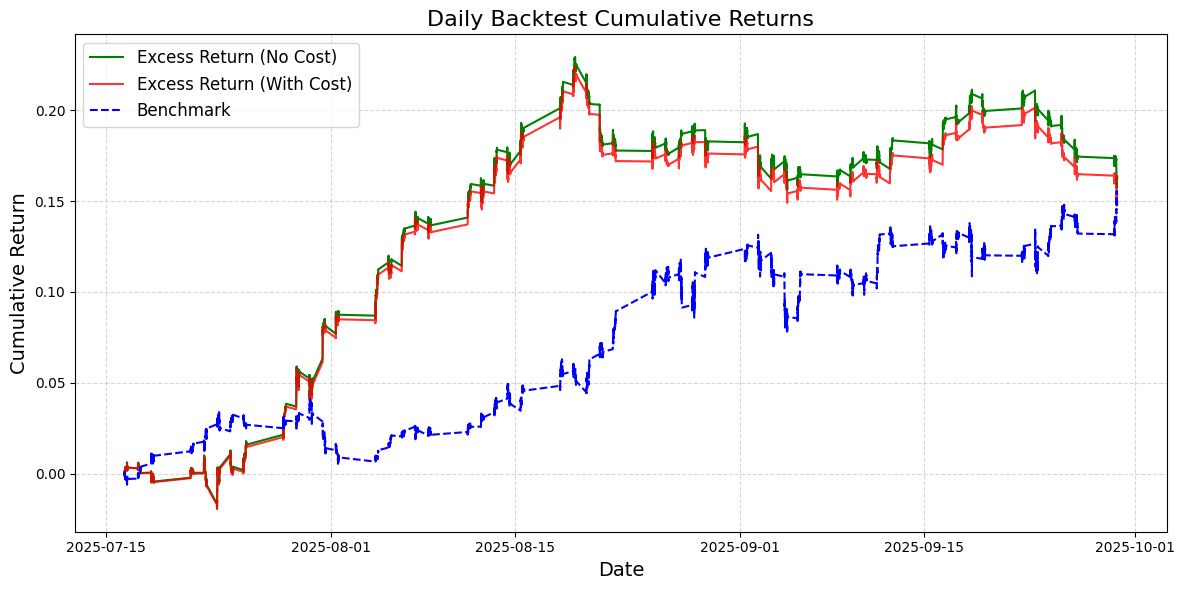

In [61]:
import matplotlib.pyplot as plt
import pandas as pd


# 1) Compute cumulative returns
cum_return_wo_cost = (1 + (report['return'] - report['bench'])).cumprod() - 1  # excess return without cost
cum_return_w_cost = (1 + (report['return'] - report['bench'] - report['cost'])).cumprod() - 1  # with cost
cum_bench = (1 + report['bench']).cumprod() - 1  # benchmark

# 2) Plot
plt.figure(figsize=(12,6))
plt.plot(cum_return_wo_cost, label='Excess Return (No Cost)', color='green')
plt.plot(cum_return_w_cost, label='Excess Return (With Cost)', color='red', alpha=0.8)
plt.plot(cum_bench, label='Benchmark', color='blue', linestyle='--')

plt.title("Daily Backtest Cumulative Returns", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Cumulative Return", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



修改调仓策略：每天只调一次仓 ，最优的交易模式应为“14:45 买入，次日 10:46 卖 出，最终采用 14:40 时刻生成的预测信号来指导当日的交易 回测报告

调仓没有分批的策略

In [54]:
import pandas as pd
import numpy as np
from qlib.backtest.signal import create_signal_from
from qlib.backtest.decision import Order, OrderDir, TradeDecisionWO
from qlib.strategy.base import BaseStrategy

class DailyTradingStrategy(BaseStrategy):
    """
    每日特定时间交易策略（覆盖原定义，类名不变）
    - 14:40 生成信号（不交易）
    - 14:45 买入（按 1 股为单位，不做按手取整）
    - 次日 10:46 卖出（全量）
    """

    def __init__(
        self,
        signal_time="14:40",
        buy_time="14:45",
        sell_time="10:46",
        topk=5,
        n_drop=0,
        signal=None,
        signal_threshold=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.signal_time = pd.Timestamp(signal_time).time()
        self.buy_time = pd.Timestamp(buy_time).time()
        self.sell_time = pd.Timestamp(sell_time).time()
        self.topk = int(topk)
        self.n_drop = int(n_drop)
        self.signal = create_signal_from(signal)
        self.signal_threshold = float(signal_threshold)
        self.daily_signals = {}

    def generate_trade_decision(self, execute_result=None):
        trade_step = self.trade_calendar.get_trade_step()
        trade_start_time, trade_end_time = self.trade_calendar.get_step_time(trade_step)
        current_time = trade_start_time.time()
        current_date = trade_start_time.date()
        
        # 14:40 仅记录信号
        if current_time == self.signal_time:
            pred_score = self.signal.get_signal(start_time=trade_start_time, end_time=trade_end_time)
            if pred_score is not None:
                if isinstance(pred_score, pd.DataFrame):
                    pred_score = pred_score.iloc[:, 0]
                self.daily_signals[current_date] = pred_score
            return TradeDecisionWO([], self)

        # 14:45 买入
        if current_time == self.buy_time:
            if current_date in self.daily_signals:
                pred_score = self.daily_signals[current_date]
                return self._generate_buy_decision(pred_score, trade_start_time, trade_end_time)
            return TradeDecisionWO([], self)

        # 次日 10:46 卖出
        if current_time == self.sell_time:
            return self._generate_sell_decision(trade_start_time, trade_end_time)

        return TradeDecisionWO([], self)

    def _safe_deal_price(self, stock: str, start_time, end_time, direction) -> float:
        try:
            price_data = self.trade_exchange.get_deal_price(
                stock_id=stock,
                start_time=start_time,
                end_time=end_time,
                direction=direction,
            )
            price = None
            if isinstance(price_data, (int, float, np.number)):
                price = float(price_data)
            elif hasattr(price_data, "iloc") and len(price_data) > 0:
                price = float(price_data.iloc[-1])
            elif hasattr(price_data, "__len__") and len(price_data) > 0:
                price = float(price_data[-1])
            if price is None or not np.isfinite(price) or price <= 0.01 or price > 1e5:
                return np.nan
            return price
        except Exception:
            return np.nan
    
    def _generate_buy_decision(self, pred_score, trade_start_time, trade_end_time):
        if pred_score is None or len(pred_score) == 0:
            return TradeDecisionWO([], self)

        # 过滤阈值并选 topk
        ser = pred_score.copy()
        if self.signal_threshold > 0:
            ser = ser[ser >= self.signal_threshold]
        if len(ser) == 0:
            return TradeDecisionWO([], self)
        target_stocks = ser.sort_values(ascending=False).head(self.topk).index.tolist()

        # 过滤可交易
        tradable = []
        for s in target_stocks:
            try:
                if self.trade_exchange.is_stock_tradable(s, trade_start_time, trade_end_time):
                    tradable.append(s)
            except Exception:
                continue
        if not tradable:
            return TradeDecisionWO([], self)

        orders = []
        cash = self.trade_position.get_cash()
        weight = 0.95 / len(tradable)
        for s in tradable:
            if s in self.trade_position.get_stock_list():
                continue
            price = self._safe_deal_price(s, trade_start_time, trade_end_time, OrderDir.BUY)
            if not np.isfinite(price):
                continue
            target_value = cash * weight
            shares = int(target_value / price)  # 1股单位（adjusted_price模式不支持按手）
            if shares < 1:
                continue
            if shares > 2_000_000:
                shares = 2_000_000
            orders.append(Order(
                stock_id=s,
                amount=shares,
                direction=OrderDir.BUY,
                start_time=trade_start_time,
                end_time=trade_end_time,
                factor=1.0
            ))
        return TradeDecisionWO(orders, self)
        
    def _generate_sell_decision(self, trade_start_time, trade_end_time):
        orders = []
        for s in list(self.trade_position.get_stock_list()):
            amount = self.trade_position.get_stock_amount(s)
            if amount <= 0:
                continue
            price = self._safe_deal_price(s, trade_start_time, trade_end_time, OrderDir.SELL)
            if not np.isfinite(price):
                continue
            orders.append(Order(
                stock_id=s,
                amount=amount,
                direction=OrderDir.SELL,
                start_time=trade_start_time,
                end_time=trade_end_time,
                factor=1.0
            ))
        return TradeDecisionWO(orders, self)

print("✅ DailyTradingStrategy 已覆盖更新：1股单位下单 + 稳健价格获取 + start/end_time 传入")


✅ DailyTradingStrategy 已覆盖更新：1股单位下单 + 稳健价格获取 + start/end_time 传入


修改策略 分批调仓、权重调整、控制交易量  回测报告完全是负数 效果不好

In [33]:
import pandas as pd
import numpy as np
from qlib.backtest.decision import TradeDecisionWO
from qlib.strategy.base import BaseStrategy
from qlib.backtest.decision import Order, OrderDir, TradeDecisionWO

class LowFreqDailyTradingStrategy(BaseStrategy):
    """低频日交易策略（分批调仓 + 固定权重 + 买卖限额）"""

    def __init__(
        self,
        signal_time="14:40",
        buy_time="14:45",
        sell_time="10:46",
        topk=5,
        signal=None,
        signal_threshold=0.0,
        n_drop=2,  
        rebalance_ratio=0.3,       # 每次调仓比例
        max_position_ratio=0.8,    # 最大总仓位比例
        min_trade_amount=10000,    # 单次最小交易额
        max_trade_amount=10000000, # 单次最大交易额
        max_sell_ratio=0.5,        # 单次卖出比例上限
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.signal_time = pd.Timestamp(signal_time).time()
        self.buy_time = pd.Timestamp(buy_time).time()
        self.sell_time = pd.Timestamp(sell_time).time()
        self.topk = int(topk)
        self.signal = signal
        self.signal_threshold = float(signal_threshold)
        self.n_drop = int(n_drop)

        # 调仓参数
        self.rebalance_ratio = float(rebalance_ratio)
        self.max_position_ratio = float(max_position_ratio)
        self.min_trade_amount = float(min_trade_amount)
        self.max_trade_amount = float(max_trade_amount)
        self.max_sell_ratio = float(max_sell_ratio)

        self.daily_signals = {}

    def generate_trade_decision(self, execute_result=None):
        trade_step = self.trade_calendar.get_trade_step()
        trade_start_time, trade_end_time = self.trade_calendar.get_step_time(trade_step)
        current_time = trade_start_time.time()
        current_date = trade_start_time.date()
        
        # 记录信号 - 修复信号获取逻辑
        if current_time == self.signal_time:
            try:
                if isinstance(self.signal, pd.Series):
                    # 如果是Series，按日期筛选信号
                    if isinstance(self.signal.index, pd.MultiIndex):
                        # MultiIndex情况：按日期筛选
                        date_mask = self.signal.index.get_level_values('datetime').date == current_date
                        if date_mask.any():
                            pred_score = self.signal[date_mask]
                        else:
                            pred_score = None
                    else:
                        # 单层Index情况：按时间筛选
                        time_mask = (self.signal.index.time == current_time)
                        if time_mask.any():
                            pred_score = self.signal[time_mask]
                        else:
                            pred_score = None
                else:
                    # 如果是Signal对象，调用get_signal
                    pred_score = self.signal.get_signal(start_time=trade_start_time, end_time=trade_end_time)

                if pred_score is not None:
                    if isinstance(pred_score, pd.DataFrame):
                        pred_score = pred_score.iloc[:, 0]
                    self.daily_signals[current_date] = pred_score
            except Exception as e:
                print(f"获取信号失败: {e}")
                pred_score = None
                
            return TradeDecisionWO([], self)

        # 买入
        if current_time == self.buy_time and current_date in self.daily_signals:
            pred_score = self.daily_signals[current_date]
            return self._generate_buy_decision(pred_score, trade_start_time, trade_end_time)

        # 卖出
        if current_time == self.sell_time:
            return self._generate_sell_decision(trade_start_time, trade_end_time)

        return TradeDecisionWO([], self)

    def _safe_deal_price(self, stock: str, start_time, end_time, direction) -> float:
        """安全获取成交价格"""
        try:
            price_data = self.trade_exchange.get_deal_price(
                stock_id=stock,
                start_time=start_time,
                end_time=end_time,
                direction=direction,
            )
            price = None
            if isinstance(price_data, (int, float, np.number)):
                price = float(price_data)
            elif hasattr(price_data, "iloc") and len(price_data) > 0:
                price = float(price_data.iloc[-1])
            elif hasattr(price_data, "__len__") and len(price_data) > 0:
                price = float(price_data[-1])
            if price is None or not np.isfinite(price) or price <= 0:
                return np.nan
            return price
        except Exception:
            return np.nan

    def _generate_buy_decision(self, pred_score, trade_start_time, trade_end_time):
        """分批买入"""
        if pred_score is None or len(pred_score) == 0:
            return TradeDecisionWO([], self)

        # 1. 筛选 topk
        ser = pred_score.copy()
        if self.signal_threshold > 0:
            ser = ser[ser >= self.signal_threshold]
        tradable = ser.sort_values(ascending=False).head(self.topk).index.tolist()
        if not tradable:
            return TradeDecisionWO([], self)

        orders = []
        cash = self.trade_position.get_cash()
        current_positions = set(self.trade_position.get_stock_list())

        # 2. 总资产估算（现金 + 当前市值）
        total_assets = cash + sum(
            self.trade_position.get_stock_amount(s) * self._safe_deal_price(s, trade_start_time, trade_end_time, OrderDir.BUY)
            for s in current_positions
        )

        # 3. 分批买入新股票
        new_stocks = [s for s in tradable if s not in current_positions]
        if new_stocks:
            rebalance_cash = total_assets * self.rebalance_ratio
            weight_per_new_stock = rebalance_cash / len(new_stocks)
            for s in new_stocks:
                price = self._safe_deal_price(s, trade_start_time, trade_end_time, OrderDir.BUY)
                if not np.isfinite(price):
                    continue
                target_value = max(self.min_trade_amount, min(weight_per_new_stock, self.max_trade_amount))
                shares = int(target_value / price)
                if shares < 1:
                    continue
                orders.append(Order(stock_id=s, amount=shares, direction=OrderDir.BUY,
                                    start_time=trade_start_time, end_time=trade_end_time, factor=1.0))

        # 4. 对现有优质股票加仓（可选）
        existing_stocks = [s for s in tradable if s in current_positions]
        if existing_stocks:
            rebalance_cash = total_assets * self.rebalance_ratio * 0.5
            weight_per_existing = rebalance_cash / len(existing_stocks)
            for s in existing_stocks:
                price = self._safe_deal_price(s, trade_start_time, trade_end_time, OrderDir.BUY)
                if not np.isfinite(price):
                    continue
                target_value = max(self.min_trade_amount, min(weight_per_existing, self.max_trade_amount))
                shares = int(target_value / price)
                if shares < 1:
                    continue
                orders.append(Order(stock_id=s, amount=shares, direction=OrderDir.BUY,
                                    start_time=trade_start_time, end_time=trade_end_time, factor=1.0))

        return TradeDecisionWO(orders, self)

    def _generate_sell_decision(self, trade_start_time, trade_end_time):
        """分批卖出"""
        orders = []
        current_positions = self.trade_position.get_stock_list()
        if not current_positions:
            return TradeDecisionWO([], self)

        for s in current_positions:
            amount = self.trade_position.get_stock_amount(s)
            if amount <= 0:
                continue
            price = self._safe_deal_price(s, trade_start_time, trade_end_time, OrderDir.SELL)
            if not np.isfinite(price):
                continue
            sell_amount = max(1, int(amount * min(self.rebalance_ratio, self.max_sell_ratio)))
            orders.append(Order(stock_id=s, amount=sell_amount, direction=OrderDir.SELL,
                                start_time=trade_start_time, end_time=trade_end_time, factor=1.0))
        return TradeDecisionWO(orders, self)



修改后的策略 正常版本 轻微负收益

In [18]:
import pandas as pd
import numpy as np
from qlib.backtest.decision import Order, OrderDir, TradeDecisionWO
from qlib.strategy.base import BaseStrategy

class WorkingLowFreqStrategy(BaseStrategy):
    """可工作的低频日交易策略"""

    def __init__(
        self,
        signal_time="14:40",
        buy_time="14:45",
        sell_time="10:46",
        topk=50,
        signal=None,
        signal_threshold=0.15,
        n_drop=3,  
        rebalance_ratio=0.2,
        max_position_ratio=0.8,
        min_trade_amount=10000,
        max_trade_amount=10000000,
        max_sell_ratio=0.2,
        **kwargs,
    ):
        super().__init__(**kwargs)
        
        self.signal_time = pd.Timestamp(signal_time).time()
        self.buy_time = pd.Timestamp(buy_time).time()
        self.sell_time = pd.Timestamp(sell_time).time()
        self.topk = int(topk)
        self.signal = signal
        self.signal_threshold = float(signal_threshold)
        self.n_drop = int(n_drop)
        self.rebalance_ratio = float(rebalance_ratio)
        self.max_position_ratio = float(max_position_ratio)
        self.min_trade_amount = float(min_trade_amount)
        self.max_trade_amount = float(max_trade_amount)
        self.max_sell_ratio = float(max_sell_ratio)
        
        self.daily_signals = {}

    def generate_trade_decision(self, execute_result=None):
        trade_step = self.trade_calendar.get_trade_step()
        trade_start_time, trade_end_time = self.trade_calendar.get_step_time(trade_step)
        current_time = trade_start_time.time()
        current_date = trade_start_time.date()
        
        # 1) 14:40 记录信号
        if current_time == self.signal_time:
            self._record_signal(current_date, trade_start_time, trade_end_time)
            return TradeDecisionWO([], self)

        # 2) 14:45 买入
        if current_time == self.buy_time:
            if current_date in self.daily_signals:
                return self._generate_buy_decision(
                    self.daily_signals[current_date], 
                    trade_start_time, 
                    trade_end_time
                )
            return TradeDecisionWO([], self)

        # 3) 10:46 卖出
        if current_time == self.sell_time:
            return self._generate_sell_decision(trade_start_time, trade_end_time)

        return TradeDecisionWO([], self)

    def _record_signal(self, current_date, trade_start_time, trade_end_time):
        """记录14:40的信号"""
        try:
            if isinstance(self.signal, pd.Series):
                if isinstance(self.signal.index, pd.MultiIndex):
                    date_mask = self.signal.index.get_level_values('datetime').date == current_date
                    if date_mask.any():
                        pred_score_all = self.signal[date_mask]
                        datetime_level = pred_score_all.index.get_level_values('datetime')
                        time_mask_14_40 = datetime_level.time == pd.Timestamp('14:40').time()
                        
                        if time_mask_14_40.any():
                            pred_score_14_40 = pred_score_all[time_mask_14_40]
                            
                            if isinstance(pred_score_14_40.index, pd.MultiIndex):
                                instrument_level = pred_score_14_40.index.get_level_values('instrument')
                                pred_score = pd.Series(pred_score_14_40.values, index=instrument_level)
                            else:
                                pred_score = pred_score_14_40
                            
                            self.daily_signals[current_date] = pred_score
        except Exception as e:
            pass
    
    def _safe_deal_price(self, stock: str, start_time, end_time, direction) -> float:
        """安全获取成交价格"""
        try:
            price_data = self.trade_exchange.get_deal_price(
                stock_id=stock,
                start_time=start_time,
                end_time=end_time,
                direction=direction,
            )
            price = None
            if isinstance(price_data, (int, float, np.number)):
                price = float(price_data)
            elif hasattr(price_data, "iloc") and len(price_data) > 0:
                price = float(price_data.iloc[-1])
            elif hasattr(price_data, "__len__") and len(price_data) > 0:
                price = float(price_data[-1])
            if price is None or not np.isfinite(price) or price <= 0:
                return np.nan
            return price
        except Exception:
            return np.nan

    def _generate_buy_decision(self, pred_score, trade_start_time, trade_end_time):
        """分批买入"""
        if pred_score is None or len(pred_score) == 0:
            return TradeDecisionWO([], self)
        
        if isinstance(pred_score.index, pd.MultiIndex):
            instrument_level = pred_score.index.get_level_values('instrument')
            pred_score = pd.Series(pred_score.values, index=instrument_level)
        
        if self.signal_threshold > 0:
            pred_score = pred_score[pred_score >= self.signal_threshold]
        if len(pred_score) == 0:
            return TradeDecisionWO([], self)
        
        top_idx = pred_score.sort_values(ascending=False).head(self.topk).index.tolist()
        if not top_idx:
            return TradeDecisionWO([], self)

        orders = []
        cash = self.trade_position.get_cash()
        current_positions = set(self.trade_position.get_stock_list())
        total_assets = cash
        for s in current_positions:
            amt = self.trade_position.get_stock_amount(s)
            if amt > 0:
                p = self._safe_deal_price(s, trade_start_time, trade_end_time, OrderDir.BUY)
                if np.isfinite(p):
                    total_assets += amt * p

        new_stocks = [s for s in top_idx if s not in current_positions]
        if new_stocks:
            rebalance_cash = total_assets * self.rebalance_ratio
            weight_per_new_stock = rebalance_cash / len(new_stocks)
            
            for s in new_stocks:
                price = self._safe_deal_price(s, trade_start_time, trade_end_time, OrderDir.BUY)
                if not np.isfinite(price) or price <= 0:
                    continue
                target_value = max(self.min_trade_amount, min(weight_per_new_stock, self.max_trade_amount))
                shares = int(target_value / price)
                if shares < 1:
                    continue
                orders.append(Order(
                    stock_id=s, 
                    amount=shares, 
                    direction=OrderDir.BUY,
                    start_time=trade_start_time, 
                    end_time=trade_end_time, 
                    factor=1.0
                ))

        existing_stocks = [s for s in top_idx if s in current_positions]
        if existing_stocks:
            rebalance_cash2 = total_assets * self.rebalance_ratio * 0.5
            weight_per_existing = rebalance_cash2 / len(existing_stocks)
            
            for s in existing_stocks:
                price = self._safe_deal_price(s, trade_start_time, trade_end_time, OrderDir.BUY)
                if not np.isfinite(price) or price <= 0:
                    continue
                target_value = max(self.min_trade_amount, min(weight_per_existing, self.max_trade_amount))
                shares = int(target_value / price)
                if shares < 1:
                    continue
                orders.append(Order(
                    stock_id=s, 
                    amount=shares, 
                    direction=OrderDir.BUY,
                    start_time=trade_start_time, 
                    end_time=trade_end_time, 
                    factor=1.0
                ))

        return TradeDecisionWO(orders, self)

    def _generate_sell_decision(self, trade_start_time, trade_end_time):
        """分批卖出"""
        orders = []
        current_positions = list(self.trade_position.get_stock_list())
        
        if not current_positions:
            return TradeDecisionWO([], self)

        for s in current_positions:
            amount = self.trade_position.get_stock_amount(s)
            if amount <= 0:
                continue
            price = self._safe_deal_price(s, trade_start_time, trade_end_time, OrderDir.SELL)
            if not np.isfinite(price) or price <= 0:
                continue
            sell_amount = max(1, int(amount * min(self.rebalance_ratio, self.max_sell_ratio)))
            orders.append(Order(
                stock_id=s, 
                amount=sell_amount, 
                direction=OrderDir.SELL,
                start_time=trade_start_time, 
                end_time=trade_end_time, 
                factor=1.0
            ))
        
        return TradeDecisionWO(orders, self)

用新策略配置的port_analysis_config_minute 和原来改了名字 加了minute

In [ ]:

port_analysis_config_minute = {
    "strategy": {
        "class": "WorkingLowFreqStrategy",  # 使用自定义策略
        "module_path": "__main__",  # 在notebook中定义，使用__main__
        "kwargs": {
            "signal": pred_processed,
            "signal_time": "14:40",  # 14:40 生成信号
            "buy_time": "14:45",     # 14:45 买入
            "sell_time": "10:46",    # 10:46 卖出
            "topk": 50,  # 减少股票数量便于测试
            "n_drop": 5,
            # 新增参数
            "rebalance_ratio": 0.2,      # 每次调仓30%
            "max_position_ratio": 0.8,   # 最大仓位80%
            "min_trade_amount": 10000,   # 最小交易1万
            "max_trade_amount": 5000000, # 最大交易500万
            "max_sell_ratio": 0.2,
            #"allowed_buy_windows": [("14:41", "14:50"), ("09:31", "10:20")],
            #"allowed_sell_windows": [("09:31", "10:20"), ("14:40", "14:58")],
            #"window_execution": "first",
        },
    },
    "executor": {
        "class": "SimulatorExecutor",
        "module_path": "qlib.backtest.executor",
        "kwargs": {
            "time_per_step": "1min",  # 保持分钟级，但策略控制交易时机
            "generate_portfolio_metrics": True,
        },
    },
    "backtest": {
        "start_time": dataset_clean.segments["test"][0],
        "end_time": None,
        "account": 1e9,
        "benchmark": "SH000300",
        "exchange_kwargs": {
            "freq": "1min",
            "deal_price": "close",  
            "limit_threshold": 0.095,   
            "open_cost": 0.0003,      
            "close_cost": 0.001,  
            "min_cost": 5,              
            "impact_cost": 0,      
           
        },
    },
}


运行成功的回测部分

In [20]:
import pandas as pd
from qlib.data.data import Cal

# 1) 预测的最后一分钟

dt_max = pred_processed.index.get_level_values("datetime").max()
dt_max = pd.Timestamp(dt_max)

# 2) 加载分钟交易日历并转成 DatetimeIndex
cal_list = Cal.load_calendar(freq="1min", future=False)  # 返回 list-like
cal_1min = pd.DatetimeIndex(cal_list)                    # 关键：转为 DatetimeIndex

# 3) 用 searchsorted 找到 dt_max 之后的“下一个交易分钟”；若没有，则裁剪到最后一分钟
pos = cal_1min.searchsorted(dt_max, side="right")
if pos >= len(cal_1min):
    # 没有更多分钟数据，回测终止在已有的最后一分钟
    # 二选一：
    next_min = dt_max             # 就停在预测的最后一分钟
    # next_min = cal_1min[-1]     # 或者停在日历中的最后一分钟（等价于 dt_max）
else:
    next_min = cal_1min[pos]

# 4) 设置回测 end_time
port_analysis_config_minute ["backtest"]["end_time"] = next_min

#显示设置生成日频报告
port_analysis_config_minute ['generate_portfolio_metrics'] = True


#运行回测并生成报告
par = PortAnaRecord(recorder, port_analysis_config_minute, risk_analysis_freq="1min")

port_analysis_config_minute["strategy"]["kwargs"]["signal"] = pred_processed
sig = port_analysis_config_minute["strategy"]["kwargs"]["signal"]
print(type(sig), sig.min(), sig.max(), sig.std())
par.generate()

# 4) 读取并展示关键结果（简版）
report = recorder.load_object("portfolio_analysis/report_normal_1min.pkl") 
analysis_df = recorder.load_object("portfolio_analysis/port_analysis_1min.pkl")  # 风险指标汇总

print("=== 核心指标（含成本，日频）===")
# 常见关键信息：超额收益、有无成本、IR、年化等（字段名可能随版本略有差异）
try:
    er_wo_cost = risk_analysis(report["return"] - report["bench"])
    er_w_cost = risk_analysis(report["return"] - report["bench"] - report["cost"])
    print("超额（无成本）:\n", er_wo_cost.round(4).to_string())
    print("\n超额（含成本）:\n", er_w_cost.round(4).to_string())
except Exception:
    print(analysis_df.round(4).to_string())

# 5) 可选：简单预览收益曲线头部
print("\n=== 回测收益曲线（头部）===")
print(report.head())

<class 'pandas.core.series.Series'> -0.9957894736842106 1.0 0.5773461550768778


[12484:MainThread](2025-10-28 13:06:28,290) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange
[12484:MainThread](2025-10-28 13:06:38,335) WARNING - qlib.online operator - [exchange.py:226] - factor.day.bin file not exists or factor contains `nan`. Order using adjusted_price.
[12484:MainThread](2025-10-28 13:06:38,336) WARNING - qlib.online operator - [exchange.py:228] - trade unit 100 is not supported in adjusted_price mode.
[12484:MainThread](2025-10-28 13:07:01,550) WARNING - qlib.data - [data.py:665] - load calendar error: freq=1min, future=True; return current calendar!
[12484:MainThread](2025-10-28 13:07:01,552) WARNING - qlib.data - [data.py:668] - You can get future calendar by referring to the following document: https://github.com/microsoft/qlib/blob/main/scripts/data_collector/contrib/README.md
[12484:MainThread](2025-10-28 13:07:01,623) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor

backtest loop:   0%|          | 0/12959 [00:00<?, ?it/s]

C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
[12484:MainThread](2025-10-28 13:09:42,845) INFO - qlib.workflow - [record_temp.py:515] - Portfolio analysis record 'port_analysis_1min.pkl' has been saved as the artifact of the Experiment 163818717121484802


'The following are analysis results of benchmark return(1min).'
                       risk
mean               0.000011
std                0.000558
annualized_return  0.625665
information_ratio  4.690492
max_drawdown      -0.049160
'The following are analysis results of the excess return without cost(1min).'
                       risk
mean               0.000012
std                0.000516
annualized_return  0.668697
information_ratio  5.426918
max_drawdown      -0.060917
'The following are analysis results of the excess return with cost(1min).'
                       risk
mean               0.000011
std                0.000516
annualized_return  0.631815
information_ratio  5.126383
max_drawdown      -0.063678


[12484:MainThread](2025-10-28 13:09:42,859) INFO - qlib.workflow - [record_temp.py:540] - Indicator analysis record 'indicator_analysis_1min.pkl' has been saved as the artifact of the Experiment 163818717121484802


'The following are analysis results of indicators(1min).'
        value
ffr  0.876759
pa   0.000000
pos  0.000000


=== 核心指标（含成本，日频）===
超额（无成本）:
                      risk
mean               0.0000
std                0.0005
annualized_return  0.0028
information_ratio  0.3503
max_drawdown      -0.0609

超额（含成本）:
                      risk
mean               0.0000
std                0.0005
annualized_return  0.0026
information_ratio  0.3309
max_drawdown      -0.0637

=== 回测收益曲线（头部）===
                          account  return  total_turnover  turnover  \
datetime                                                              
2025-07-16 09:30:00  1.000000e+09     0.0             0.0       0.0   
2025-07-16 09:31:00  1.000000e+09     0.0             0.0       0.0   
2025-07-16 09:32:00  1.000000e+09     0.0             0.0       0.0   
2025-07-16 09:33:00  1.000000e+09     0.0             0.0       0.0   
2025-07-16 09:34:00  1.000000e+09     0.0             0.0       0.0   

                     total_cost  cost  value          cash     bench  
datetime                                                   

In [39]:
print(pred_processed.describe())


count    6.155050e+06
mean     2.105263e-03
std      5.773462e-01
min     -9.957895e-01
25%     -4.989474e-01
50%      2.105263e-03
75%      5.031579e-01
max      1.000000e+00
dtype: float64


执行多空收益分解分析...
多头空头收益分解分析



✅ 图表已保存: examples/highfreq/long_short_decomposition.png


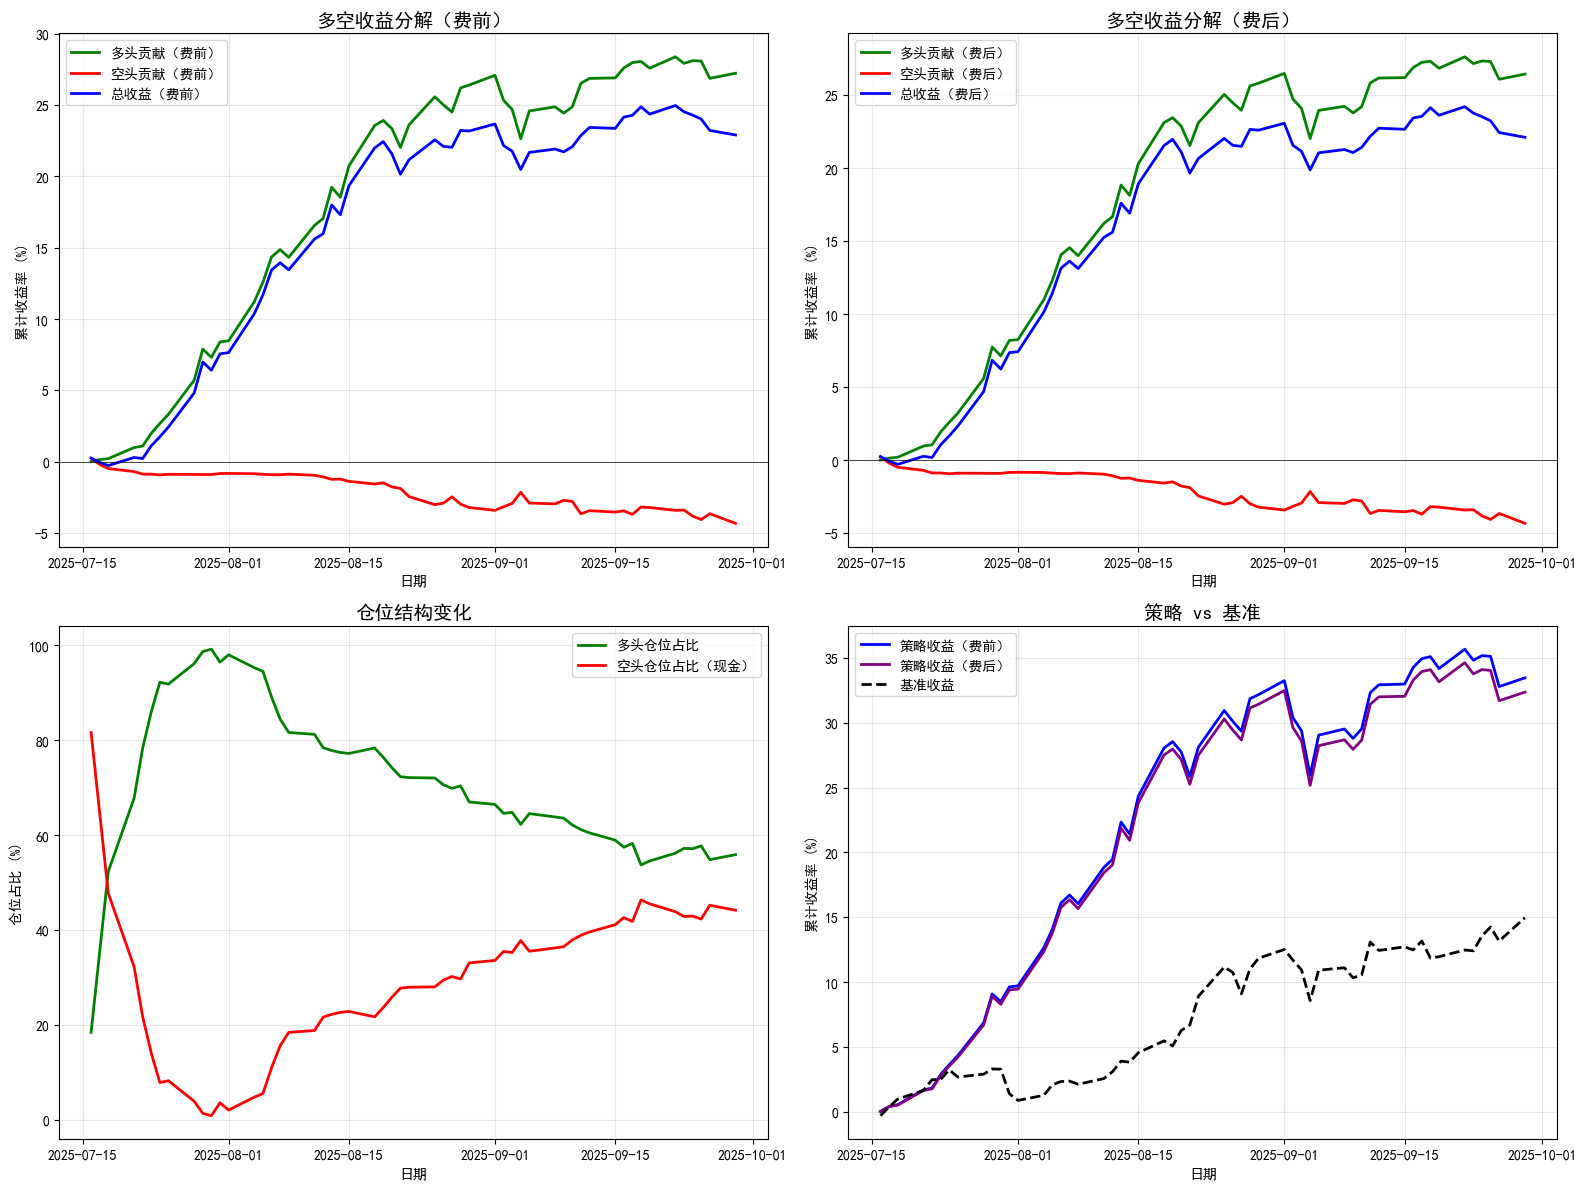


多空收益统计

费前收益:
  多头贡献: 27.22%
  空头贡献: -4.32%
  总收益: 22.89%

费后收益:
  多头贡献: 26.43%
  空头贡献: -4.32%
  总收益: 22.11%

平均仓位:
  平均多头仓位: 70.83%
  平均空头仓位: 29.17%

✅ 分析完成！


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

def analyze_long_short_decomposition(recorder, freq_suffix="1min"):
    """
    完整的多空收益分解分析
    """
    
    print("=" * 70)
    print("多头空头收益分解分析")
    print("=" * 70)
    
    # 1. 加载数据
    report = recorder.load_object(f"portfolio_analysis/report_normal_{freq_suffix}.pkl")
    
    rpt = report.copy()
    if not isinstance(rpt.index, pd.DatetimeIndex):
        rpt.index = pd.to_datetime(rpt.index)
    rpt = rpt.sort_index()
    
    # 2. 按日聚合
    daily_rpt = rpt.groupby(rpt.index.normalize()).agg({
        'return': 'sum',
        'bench': 'sum',
        'cost': 'sum',
        'account': 'last',
        'value': 'last',  # 持仓市值
        'cash': 'last',
    })
    
    # 3. 计算累计收益
    daily_rpt['cum_strategy'] = (1 + daily_rpt['return']).cumprod() - 1
    daily_rpt['cum_strategy_cost'] = (1 + daily_rpt['return'] - daily_rpt['cost']).cumprod() - 1
    daily_rpt['cum_bench'] = (1 + daily_rpt['bench']).cumprod() - 1
    
    # 4. 多头收益 = 策略收益（您的是纯多头策略）
    # 空头收益 = 0（因为没有做空）
    # 但我们可以用"相对基准的超额"作为近似
    
    # 多头贡献（策略实现的实际收益）
    daily_rpt['long_contribution_before_cost'] = daily_rpt['return']
    daily_rpt['long_contribution_after_cost'] = daily_rpt['return'] - daily_rpt['cost']
    
    # 5. 创建多头空头视角
    # 在纯多头策略中：
    # - 策略多头 = 实际持有股票
    # - 隐含空头 = 现金持有（相比满仓基准的超额）
    
    initial_capital = daily_rpt['account'].iloc[0]
    
    # 多头仓位比例
    daily_rpt['long_position_ratio'] = daily_rpt['value'] / (daily_rpt['account'])
    
    # 隐含空头仓位 = 1 - 多头仓位
    daily_rpt['short_position_ratio'] = 1 - daily_rpt['long_position_ratio']
    
    # 多头收益（费前）
    daily_rpt['long_return_before'] = daily_rpt['long_contribution_before_cost'] * daily_rpt['long_position_ratio']
    
    # 空头收益（考虑现金的"做空"效果）
    # 空头收益 = 市场下跌时持有的现金比例带来的相对收益
    daily_rpt['short_return_before'] = daily_rpt['short_position_ratio'] * (-daily_rpt['bench'])
    
    # 计算累计
    daily_rpt['cum_long_before'] = (1 + daily_rpt['long_return_before']).cumprod() - 1
    daily_rpt['cum_short_before'] = (1 + daily_rpt['short_return_before']).cumprod() - 1
    daily_rpt['cum_long_after'] = (1 + daily_rpt['long_contribution_after_cost'] * daily_rpt['long_position_ratio']).cumprod() - 1
    daily_rpt['cum_short_after'] = (1 + daily_rpt['short_return_before']).cumprod() - 1
    
    # 6. 绘图
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 图1: 费前多空收益
    ax1 = axes[0, 0]
    ax1.plot(daily_rpt.index, daily_rpt['cum_long_before'] * 100, 
             label='多头贡献（费前）', linewidth=2, color='green')
    ax1.plot(daily_rpt.index, daily_rpt['cum_short_before'] * 100, 
             label='空头贡献（费前）', linewidth=2, color='red')
    ax1.plot(daily_rpt.index, (daily_rpt['cum_long_before'] + daily_rpt['cum_short_before']) * 100, 
             label='总收益（费前）', linewidth=2, color='blue')
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax1.set_title('多空收益分解（费前）', fontsize=14, fontweight='bold')
    ax1.set_xlabel('日期')
    ax1.set_ylabel('累计收益率 (%)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 图2: 费后多空收益
    ax2 = axes[0, 1]
    ax2.plot(daily_rpt.index, daily_rpt['cum_long_after'] * 100, 
             label='多头贡献（费后）', linewidth=2, color='green')
    ax2.plot(daily_rpt.index, daily_rpt['cum_short_after'] * 100, 
             label='空头贡献（费后）', linewidth=2, color='red')
    ax2.plot(daily_rpt.index, (daily_rpt['cum_long_after'] + daily_rpt['cum_short_after']) * 100, 
             label='总收益（费后）', linewidth=2, color='blue')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.set_title('多空收益分解（费后）', fontsize=14, fontweight='bold')
    ax2.set_xlabel('日期')
    ax2.set_ylabel('累计收益率 (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 图3: 仓位变化
    ax3 = axes[1, 0]
    ax3.plot(daily_rpt.index, daily_rpt['long_position_ratio'] * 100, 
             label='多头仓位占比', linewidth=2, color='green')
    ax3.plot(daily_rpt.index, daily_rpt['short_position_ratio'] * 100, 
             label='空头仓位占比（现金）', linewidth=2, color='red')
    ax3.set_title('仓位结构变化', fontsize=14, fontweight='bold')
    ax3.set_xlabel('日期')
    ax3.set_ylabel('仓位占比 (%)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 图4: 策略 vs 基准
    ax4 = axes[1, 1]
    ax4.plot(daily_rpt.index, daily_rpt['cum_strategy'] * 100, 
             label='策略收益（费前）', linewidth=2, color='blue')
    ax4.plot(daily_rpt.index, daily_rpt['cum_strategy_cost'] * 100, 
             label='策略收益（费后）', linewidth=2, color='purple')
    ax4.plot(daily_rpt.index, daily_rpt['cum_bench'] * 100, 
             label='基准收益', linewidth=2, color='black', linestyle='--')
    ax4.set_title('策略 vs 基准', fontsize=14, fontweight='bold')
    ax4.set_xlabel('日期')
    ax4.set_ylabel('累计收益率 (%)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('examples/highfreq/long_short_decomposition.png', dpi=300, bbox_inches='tight')
    print("\n✅ 图表已保存: examples/highfreq/long_short_decomposition.png")
    
    plt.show()
    
    # 7. 输出统计
    print("\n" + "=" * 70)
    print("多空收益统计")
    print("=" * 70)
    
    final_long_before = daily_rpt['cum_long_before'].iloc[-1]
    final_short_before = daily_rpt['cum_short_before'].iloc[-1]
    final_long_after = daily_rpt['cum_long_after'].iloc[-1]
    final_short_after = daily_rpt['cum_short_after'].iloc[-1]
    
    print(f"\n费前收益:")
    print(f"  多头贡献: {final_long_before*100:.2f}%")
    print(f"  空头贡献: {final_short_before*100:.2f}%")
    print(f"  总收益: {(final_long_before+final_short_before)*100:.2f}%")
    
    print(f"\n费后收益:")
    print(f"  多头贡献: {final_long_after*100:.2f}%")
    print(f"  空头贡献: {final_short_after*100:.2f}%")
    print(f"  总收益: {(final_long_after+final_short_after)*100:.2f}%")
    
    print(f"\n平均仓位:")
    print(f"  平均多头仓位: {daily_rpt['long_position_ratio'].mean()*100:.2f}%")
    print(f"  平均空头仓位: {daily_rpt['short_position_ratio'].mean()*100:.2f}%")
    
    return daily_rpt, fig

# 执行分析
print("执行多空收益分解分析...")
result, fig = analyze_long_short_decomposition(recorder, freq_suffix="1min")

print("\n✅ 分析完成！")



基于回测的交易统计

In [62]:
import numpy as np
import pandas as pd

def compute_trade_stats_from_artifacts(
    recorder,
    initial_capital=1_000_000.0,
    freq_suffix="1min",  # 与你的回测一致
):
    # 1) 加载基础对象
    report = recorder.load_object(f"portfolio_analysis/report_normal_{freq_suffix}.pkl")
    try:
        positions = recorder.load_object(f"portfolio_analysis/positions_normal_{freq_suffix}.pkl")
    except Exception:
        positions = None
    try:
        orders = recorder.load_object(f"portfolio_analysis/orders_normal_{freq_suffix}.pkl")
    except Exception:
        orders = None

    # 2) 统一索引为 DatetimeIndex，按时间排序
    rpt = report.copy()
    if not isinstance(rpt.index, pd.DatetimeIndex):
        rpt.index = pd.to_datetime(rpt.index)
    rpt = rpt.sort_index()

    # 3) 如果有订单明细，直接基于订单汇总（最精确）
    # 期望订单表包含: datetime, instrument, direction(BUY/SELL), price, amount, commission, slippage 等
    if orders is not None and isinstance(orders, (pd.DataFrame, pd.Series)) and len(orders) > 0:
        od = orders.copy()
        if not isinstance(od.index, pd.DatetimeIndex):
            if "datetime" in od.columns:
                od.index = pd.to_datetime(od["datetime"])
            else:
                od.index = pd.to_datetime(od.index)
        od = od.sort_index()

        # 标准字段名兼容处理
        dir_col = "direction" if "direction" in od.columns else "dir"
        price_col = "price" if "price" in od.columns else "$price" if "$price" in od.columns else None
        amount_col = "amount" if "amount" in od.columns else "volume" if "volume" in od.columns else None
        comm_col = "commission" if "commission" in od.columns else "cost_commission" if "cost_commission" in od.columns else None
        slip_col = "slippage" if "slippage" in od.columns else "cost_slippage" if "cost_slippage" in od.columns else None

        # 仅保留有效行
        if price_col is None or amount_col is None:
            # 无法从订单直接计算成交额，则退化到 report 路径
            orders = None
        else:
            od["trade_value"] = od[price_col].astype(float) * od[amount_col].astype(float)
            od["is_buy"] = od[dir_col].astype(str).str.upper().str.contains("BUY")
            od["is_sell"] = od[dir_col].astype(str).str.upper().str.contains("SELL")

            # 当日统计：成交笔数、总成交额、买入/卖出、手续费、滑点
            daily = pd.DataFrame(index=od.index.normalize().sort_values().unique())
            daily["trade_count"] = od.groupby(od.index.normalize()).size()

            daily["turnover"] = od.groupby(od.index.normalize())["trade_value"].sum()
            daily["buy_amount"] = od.loc[od["is_buy"]].groupby(od.loc[od["is_buy"]].index.normalize())["trade_value"].sum().reindex(daily.index, fill_value=0.0)
            daily["sell_amount"] = od.loc[od["is_sell"]].groupby(od.loc[od["is_sell"]].index.normalize())["trade_value"].sum().reindex(daily.index, fill_value=0.0)
            
            if comm_col in od.columns:
                daily["commission_total"] = od.groupby(od.index.normalize())[comm_col].sum()
            else:
                daily["commission_total"] = 0.0

            if slip_col in od.columns:
                daily["slippage_total"] = od.groupby(od.index.normalize())[slip_col].sum()
            else:
                daily["slippage_total"] = 0.0

            daily["net_investment"] = daily["buy_amount"] - daily["sell_amount"]

            # 用 report 的逐分钟 return/cost 推导每日毛/净收益（币值）
            # 逐分钟滚动权益
            equity = pd.Series(index=rpt.index, dtype="float64")
            equity.iloc[0] = initial_capital
            gross_ret = rpt["return"].astype(float)
            cost_ret = rpt["cost"].astype(float) if "cost" in rpt.columns else 0.0
            for i in range(1, len(rpt)):
                prev = equity.iloc[i - 1]
                net_r = float(gross_ret.iloc[i] - (cost_ret.iloc[i] if isinstance(cost_ret, pd.Series) else cost_ret))
                equity.iloc[i] = prev * (1.0 + net_r)

            # 分解到“当日毛/净收益”和“当日手续费”（以 report 的 cost 为总交易费用近似）
            eq_prev = equity.shift(1).fillna(initial_capital)
            pnl_gross_min = eq_prev * gross_ret
            pnl_cost_min = eq_prev * (cost_ret if isinstance(cost_ret, pd.Series) else 0.0)
            pnl_net_min = pnl_gross_min - pnl_cost_min

            agg = pd.DataFrame({
                "gross_pnl": pnl_gross_min.groupby(pnl_gross_min.index.normalize()).sum(),
                "net_pnl": pnl_net_min.groupby(pnl_net_min.index.normalize()).sum(),
                "commission_like_total": pnl_cost_min.groupby(pnl_cost_min.index.normalize()).sum(),
            })
            daily = daily.join(agg, how="outer").fillna(0.0)
            
            # 收盘持仓市值与现金余额（若需要，可由 report/positions 进一步精化）
            # 这里用权益末值与累计净收益“近似”：
            by_day_last_equity = equity.groupby(equity.index.normalize()).last()
            daily["total_value"] = by_day_last_equity.reindex(daily.index).ffill().fillna(initial_capital)
            # 由于缺少持仓/现金拆分，这里仅输出总权益；如需拆分，结合 positions 求“收盘价*持仓量”。

            # 汇总（全周期）
            total_stats = {
                "total_trades": int(daily["trade_count"].sum()),
                "total_turnover": float(daily["turnover"].sum()),
                "total_buy_amount": float(daily["buy_amount"].sum()),
                "total_sell_amount": float(daily["sell_amount"].sum()),
                "total_commission": float(daily["commission_total"].sum()),
                "total_slippage": float(daily["slippage_total"].sum()),
                "total_gross_pnl": float(daily["gross_pnl"].sum()),
                "total_net_pnl": float(daily["net_pnl"].sum()),
            }
            return daily, total_stats

    # 4) 无订单明细时：基于 report 的逐分钟收益与成本“重建”每日统计（近似）
    equity = pd.Series(index=rpt.index, dtype="float64")
    equity.iloc[0] = initial_capital

    gross_ret = rpt["return"].astype(float)
    cost_ret = rpt["cost"].astype(float) if "cost" in rpt.columns else 0.0

    for i in range(1, len(rpt)):
        prev = equity.iloc[i - 1]
        net_r = float(gross_ret.iloc[i] - (cost_ret.iloc[i] if isinstance(cost_ret, pd.Series) else cost_ret))
        equity.iloc[i] = prev * (1.0 + net_r)

    eq_prev = equity.shift(1).fillna(initial_capital)
    pnl_gross_min = eq_prev * gross_ret
    pnl_cost_min = eq_prev * (cost_ret if isinstance(cost_ret, pd.Series) else 0.0)
    pnl_net_min = pnl_gross_min - pnl_cost_min

    # 日度统计
    daily = pd.DataFrame(index=rpt.index.normalize().unique())
    daily["trade_count"] = np.nan  # 无订单明细，无法精确给出成交笔数
    # 若 report 有 turnover（换手率），则用“换手率×前一时刻权益”的分钟成交额累加近似成交额
    if "turnover" in rpt.columns:
        turnover_min_amount = eq_prev * rpt["turnover"].astype(float)
        daily["turnover"] = turnover_min_amount.groupby(turnover_min_amount.index.normalize()).sum()
    else:
        daily["turnover"] = np.nan

    daily["buy_amount"] = np.nan
    daily["sell_amount"] = np.nan
    daily["commission_total"] = pnl_cost_min.groupby(pnl_cost_min.index.normalize()).sum()
    daily["slippage_total"] = np.nan  # 未分拆，无法区分佣金/滑点
    daily["net_investment"] = np.nan
    daily["gross_pnl"] = pnl_gross_min.groupby(pnl_gross_min.index.normalize()).sum()
    daily["net_pnl"] = pnl_net_min.groupby(pnl_net_min.index.normalize()).sum()
    by_day_last_equity = equity.groupby(equity.index.normalize()).last()
    daily["total_value"] = by_day_last_equity

    total_stats = {
        "total_trades": np.nan,
        "total_turnover": float(daily["turnover"].sum()) if daily["turnover"].notna().any() else np.nan,
        "total_buy_amount": np.nan,
        "total_sell_amount": np.nan,
        "total_commission": float(daily["commission_total"].sum()),
        "total_slippage": np.nan,
        "total_gross_pnl": float(daily["gross_pnl"].sum()),
        "total_net_pnl": float(daily["net_pnl"].sum()),
    }
    return daily, total_stats

# === 用法（放在你的 par.generate() 和加载 report 之后）===
_report = recorder.load_object("portfolio_analysis/report_normal_1min.pkl")
init_cap = float(_report["account"].iloc[0])

daily_stats, total_stats = compute_trade_stats_from_artifacts(
    recorder,
    initial_capital=init_cap,  # 用报告初值，避免金额失真
    freq_suffix="1min",
)

# ---- 生成 daily_trade_count（近似，基于持仓变化），若失败则置0 ----
try:
    positions = recorder.load_object("portfolio_analysis/positions_normal_1min.pkl")
    pos_map = positions  # dict: {timestamp -> Position}
    import pandas as pd

    # 全部时间点
    idx = pd.DatetimeIndex(sorted(pos_map.keys()))
    dates = pd.DatetimeIndex(sorted(set(ts.normalize() for ts in idx)))

    def position_to_series(pos_obj):
        # Position -> Series(symbol -> amount)
        stocks = pos_obj.get_stock_list()
        if not stocks:
            return pd.Series(dtype=float)
        data = {s: float(pos_obj.get_stock_amount(s)) for s in stocks}
        return pd.Series(data, dtype=float)

    def pick_ts(date: pd.Timestamp, hhmm: str):
        t = pd.Timestamp(f"{date.date()} {hhmm}:00")
        if t in pos_map:
            return t
        loc = idx.searchsorted(t)
        if loc < len(idx) and idx[loc].normalize() == date:
            return idx[loc]
        if loc > 0 and idx[loc - 1].normalize() == date:
            return idx[loc - 1]
        return None

    def count_changes_at(date: pd.Timestamp, hhmm: str, hhmm_prev: str) -> int:
        t_now = pick_ts(date, hhmm)
        t_prev = pick_ts(date, hhmm_prev)
        if t_now is None or t_prev is None:
            return 0
        s_now = position_to_series(pos_map[t_now]).fillna(0.0)
        s_prev = position_to_series(pos_map[t_prev]).fillna(0.0)
        uni = s_now.index.union(s_prev.index)
        s_now = s_now.reindex(uni, fill_value=0.0)
        s_prev = s_prev.reindex(uni, fill_value=0.0)
        return int((s_now != s_prev).sum())

    rows = []
    for d in dates:
        cnt = count_changes_at(d, "14:45", "14:44") + count_changes_at(d, "10:46", "10:45")
        rows.append((d, cnt))
    daily_trade_count = pd.DataFrame(rows, columns=["date","trade_count"]).set_index("date").sort_index()
except Exception:
    # 持仓不可用时，置0列
    daily_trade_count = pd.DataFrame({"trade_count": 0}, index=daily_stats.index)

# ---- 合并近似成交笔数 ----
daily_trade_count_approx = daily_trade_count.rename(columns={"trade_count": "trade_count_pos"})

# 合并
daily_stats = daily_stats.join(daily_trade_count_approx, how="left")

# 若已有 trade_count 列：用近似值回填；若没有：直接用近似值
if "trade_count" in daily_stats.columns:
    daily_stats["trade_count"] = (
        daily_stats["trade_count"]
        .fillna(daily_stats["trade_count_pos"])
        .fillna(0)
        .astype(int)
    )
else:
    daily_stats["trade_count"] = daily_stats["trade_count_pos"].fillna(0).astype(int)

# 清理中间列
daily_stats = daily_stats.drop(columns=["trade_count_pos"])

# ---- 兼容 turnover 列名差异（compute_trade_stats 内已处理，这里仅兜底）----
if "turnover" not in daily_stats.columns:
    daily_stats["turnover"] = 0.0

# ---- 汇总输出 ----
# 若 compute_trade_stats_from_artifacts 返回 total_trades 为 NaN（无订单文件），用近似笔数替代
if total_stats.get("total_trades") is None or (isinstance(total_stats.get("total_trades"), float) and np.isnan(total_stats["total_trades"])):
    total_stats["total_trades"] = int(daily_stats["trade_count"].sum())

print("\n=== 全周期统计（含近似成交笔数）===")
for k, v in total_stats.items():
    print(f"{k}: {v}")

print("\n=== 日度统计（前10天）===")
print(daily_stats.head(10))


=== 全周期统计（含近似成交笔数）===
total_trades: 19813
total_turnover: 15733842059.3643
total_buy_amount: nan
total_sell_amount: nan
total_commission: 10087872.645680128
total_slippage: nan
total_gross_pnl: 336774515.8762206
total_net_pnl: 326686643.23054045

=== 日度统计（前10天）===
            trade_count      turnover  buy_amount  sell_amount  \
datetime                                                         
2025-07-16           46  1.839991e+08         NaN          NaN   
2025-07-17           90  2.392559e+08         NaN          NaN   
2025-07-18          128  3.010275e+08         NaN          NaN   
2025-07-21          153  3.388862e+08         NaN          NaN   
2025-07-22          178  3.531481e+08         NaN          NaN   
2025-07-23          211  3.704123e+08         NaN          NaN   
2025-07-24          230  3.675924e+08         NaN          NaN   
2025-07-25          251  3.310263e+08         NaN          NaN   
2025-07-28          271  3.991052e+08         NaN          NaN   
2025-07-

In [60]:
def realistic_strategy_evaluation(recorder, freq_suffix="1min"):
    """现实主义的策略评估"""
    
    report = recorder.load_object(f"portfolio_analysis/report_normal_{freq_suffix}.pkl")
    rpt = report.copy()
    if not isinstance(rpt.index, pd.DatetimeIndex):
        rpt.index = pd.to_datetime(rpt.index)
    rpt = rpt.sort_index()
    
    init_cap = float(rpt['account'].iloc[0])
    final_cap = float(rpt['account'].iloc[-1])
    
    print("=== 现实主义策略评估 ===")
    
    # 1. 实际表现（不年化）
    total_return = (final_cap / init_cap - 1) * 100
    actual_days = (rpt.index[-1] - rpt.index[0]).days
    monthly_return = total_return / (actual_days / 30.44)  # 平均月收益
    
    print(f"实际期间: {actual_days}天 ({actual_days/30.44:.1f}个月)")
    print(f"实际收益率: {total_return:.2f}%")
    print(f"平均月收益率: {monthly_return:.2f}%")
    
    # 2. 风险调整指标
    daily_returns = rpt.groupby(rpt.index.normalize()).agg({'return': 'sum'})['return']
    
    # 夏普比率（更保守的计算）
    risk_free_rate = 0.03  # 假设无风险利率3%
    excess_returns = daily_returns - risk_free_rate/252
    sharpe_ratio = excess_returns.mean() / daily_returns.std() * np.sqrt(252)
    
    print(f"夏普比率: {sharpe_ratio:.4f}")
    
    # 3. 最大回撤
    cumulative_returns = (1 + daily_returns).cumprod()
    running_max = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    
    print(f"最大回撤: {max_drawdown:.4f} ({max_drawdown*100:.2f}%)")
    
    # 4. 收益稳定性
    positive_days = (daily_returns > 0).sum()
    total_trading_days = len(daily_returns)
    win_rate = positive_days / total_trading_days
    
    print(f"胜率: {win_rate:.4f} ({win_rate*100:.2f}%)")
    
    # 5. 收益/成交额比率
    total_turnover = rpt['total_turnover'].iloc[-1]
    total_net_pnl = final_cap - init_cap
    profit_turnover_ratio = total_net_pnl / total_turnover
    
    print(f"收益/成交额比率: {profit_turnover_ratio:.6f} ({profit_turnover_ratio*1000:.2f}‰)")
    
    # 6. 现实性评估
    print(f"\n=== 现实性评估 ===")
    
    if monthly_return > 50:
        print("⚠️ 月收益率过高，可能存在数据问题或过度拟合")
    elif monthly_return > 20:
        print("✅ 月收益率优秀，但需要谨慎验证")
    elif monthly_return > 10:
        print("✅ 月收益率良好")
    else:
        print("✅ 月收益率合理")
    
    if sharpe_ratio > 5:
        print("⚠️ 夏普比率过高，可能存在数据问题")
    elif sharpe_ratio > 2:
        print("✅ 夏普比率优秀")
    elif sharpe_ratio > 1:
        print("✅ 夏普比率良好")
    else:
        print("⚠️ 夏普比率一般")
    
    if max_drawdown > -0.2:
        print("✅ 最大回撤控制良好")
    elif max_drawdown > -0.1:
        print("✅ 最大回撤可接受")
    else:
        print("⚠️ 最大回撤较大")
    
    # 7. 建议
    print(f"\n=== 建议 ===")
    print("1. 数据期间较短（5个月），年化收益率仅供参考")
    print("2. 重点关注实际月收益率和风险控制")
    print("3. 建议延长回测期间验证策略稳定性")
    print("4. 考虑实盘验证前先进行更长时间的回测")
    
    return {
        'actual_days': actual_days,
        'total_return': total_return,
        'monthly_return': monthly_return,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'profit_turnover_ratio': profit_turnover_ratio
    }

# 运行现实主义评估
realistic_eval = realistic_strategy_evaluation(recorder, freq_suffix="1min")

=== 现实主义策略评估 ===
实际期间: 75天 (2.5个月)
实际收益率: 32.67%
平均月收益率: 13.26%
夏普比率: 6.6548
最大回撤: -0.0548 (-5.48%)
胜率: 0.7222 (72.22%)
收益/成交额比率: 0.020763 (20.76‰)

=== 现实性评估 ===
✅ 月收益率良好
⚠️ 夏普比率过高，可能存在数据问题
✅ 最大回撤控制良好

=== 建议 ===
1. 数据期间较短（5个月），年化收益率仅供参考
2. 重点关注实际月收益率和风险控制
3. 建议延长回测期间验证策略稳定性
4. 考虑实盘验证前先进行更长时间的回测


In [43]:
# 完整的正确评估代码
import pandas as pd
import numpy as np

freq_suffix = "1min"
report = recorder.load_object(f"portfolio_analysis/report_normal_{freq_suffix}.pkl")
rpt = report.copy()

if not isinstance(rpt.index, pd.DatetimeIndex):
    rpt.index = pd.to_datetime(rpt.index)
rpt = rpt.sort_index()

print("=" * 70)
print("正确的回测评估计算")
print("=" * 70)

# 基本信息
init_cap = float(rpt['account'].iloc[0])
final_cap = float(rpt['account'].iloc[-1])
net_profit = final_cap - init_cap

print(f"\n📊 基本信息")
print(f"初始资金: {init_cap:,.0f}")
print(f"最终资金: {final_cap:,.0f}")
print(f"净利润: {net_profit:,.0f}")

# 按日聚合
daily_rpt = rpt.groupby(rpt.index.normalize()).agg({
    'account': 'last',
    'return': 'sum',
    'cost': 'sum',
    'total_turnover': 'last',
})

trading_days = len(daily_rpt)

# 关键：计算每日成交额增量
daily_total_turnover = daily_rpt['total_turnover']
daily_turnover_increment = daily_total_turnover.diff().fillna(daily_total_turnover.iloc[0])
total_trade_volume = daily_turnover_increment.sum()

print(f"\n📈 成交额分析")
print(f"交易日数: {trading_days}")
print(f"每日成交额平均: {daily_turnover_increment.mean():,.0f}")
print(f"总成交额: {total_trade_volume:,.0f}")

# 成本分析
total_cost = daily_rpt['cost'].sum()

print(f"\n💰 成本分析")
print(f"总成本: {total_cost:,.0f}")
print(f"成本占净利润: {total_cost/net_profit*100:.2f}%")

# 收益/成交额比率 - 正确的计算
profit_turnover_ratio = net_profit / total_trade_volume if total_trade_volume > 0 else 0

print(f"\n📊 核心指标")
print(f"净利润: {net_profit:,.0f}")
print(f"总成交额: {total_trade_volume:,.0f}")
print(f"收益/成交额比率: {profit_turnover_ratio:.6f} ({profit_turnover_ratio*1000:.3f}‰)")

# 收益率
simple_return = (final_cap / init_cap - 1) * 100
annualized_return = ((final_cap / init_cap) ** (252 / trading_days) - 1) * 100

print(f"\n📈 收益率")
print(f"总收益率: {simple_return:.2f}%")
print(f"年化收益率: {annualized_return:.2f}%")

# 风险指标
daily_returns = daily_rpt['return']
positive_days = (daily_returns > 0).sum()
win_rate = positive_days / trading_days

sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if daily_returns.std() > 0 else 0

cumulative_returns = (1 + daily_returns).cumprod()
running_max = cumulative_returns.expanding().max()
drawdown = (cumulative_returns - running_max) / running_max
max_drawdown = drawdown.min()

print(f"\n📉 风险指标")
print(f"胜率: {win_rate*100:.2f}%")
print(f"夏普比率: {sharpe_ratio:.4f}")
print(f"最大回撤: {max_drawdown*100:.2f}%")
print(f"\n" + "=" * 70)
print("最终结果")
print("=" * 70)
print(f"收益/成交额比率: {profit_turnover_ratio*1000:.2f}‰")

# 判断
if profit_turnover_ratio > 0.05:
    print(f"⚠️ {profit_turnover_ratio*1000:.1f}‰ 过高")
elif profit_turnover_ratio > 0.01:
    print(f"✅ {profit_turnover_ratio*1000:.1f}‰ 较高")
else:
    print(f"✅ {profit_turnover_ratio*1000:.1f}‰ 合理")

正确的回测评估计算

📊 基本信息
初始资金: 1,000,000,000
最终资金: 1,181,461,373
净利润: 181,461,373

📈 成交额分析
交易日数: 54
每日成交额平均: 92,726,006
总成交额: 5,007,204,338

💰 成本分析
总成本: 0
成本占净利润: 0.00%

📊 核心指标
净利润: 181,461,373
总成交额: 5,007,204,338
收益/成交额比率: 0.036240 (36.240‰)

📈 收益率
总收益率: 18.15%
年化收益率: 117.75%

📉 风险指标
胜率: 75.93%
夏普比率: 8.2692
最大回撤: -2.52%

最终结果
收益/成交额比率: 36.24‰
✅ 36.2‰ 较高
